<a href="https://colab.research.google.com/github/myriosMin/EDA-practice/blob/main/233523A_MinPhyoThura_T2_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import datasets and libraries


##Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import datetime as dt
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

##Import the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
path = '/content/drive/MyDrive/NYP/Year2/DataPrep&Vis/Data/Assign_Dataset'
theme_l = pd.read_csv(path + '/Theme_list.csv')
theme_pl = pd.read_csv(path + '/Theme_product_list.csv')
search = pd.read_csv(path + '/google_search_data.csv')
manu = pd.read_csv(path + '/product_manufacturer_list.csv')
sales = pd.read_csv(path + '/sales_data.csv')
social = pd.read_csv(path + '/social_media_data.csv')

##Inspect the datasets

In [ ]:
#theme_list.csv
print(theme_l.head())
theme_l.info()

   CLAIM_ID Claim Name
0         0   No Claim
1         8   low carb
2        15      beans
3        16      cocoa
4        26    vanilla
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CLAIM_ID    208 non-null    int64 
 1   Claim Name  208 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.4+ KB


In [ ]:
#theme and claim have the same meaning

#renaming the columns for consistency
theme_l.rename(columns={'CLAIM_ID': 'theme_id', 'Claim Name': 'theme_name'}, inplace=True)
theme_l.columns
#respective data types are correct; no change is needed

Index(['theme_id', 'theme_name'], dtype='object')

In [ ]:
#theme-to-product.csv
print(theme_pl.head())
theme_pl.info()

   PRODUCT_ID  CLAIM_ID
0          26         8
1          29         8
2          48        81
3          50        81
4          74       227
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91485 entries, 0 to 91484
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   PRODUCT_ID  91485 non-null  int64
 1   CLAIM_ID    91485 non-null  int64
dtypes: int64(2)
memory usage: 1.4 MB


In [ ]:
#renaming the columns
theme_pl.rename(columns={'PRODUCT_ID': 'product_id', 'CLAIM_ID': 'theme_id'}, inplace=True)
theme_pl.columns
#data types are already correct

Index(['product_id', 'theme_id'], dtype='object')

In [ ]:
#search.csv
print(search.head())
search.info()

         date platform  searchVolume  Claim_ID  week_number  year_new
0  05-01-2014   google           349       916            1      2014
1  06-01-2014   google           349       916            2      2014
2  07-01-2014   google           697       916            2      2014
3  10-01-2014   google           349       916            2      2014
4  20-01-2014   google           697       916            4      2014
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181565 entries, 0 to 181564
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   date          181565 non-null  object
 1   platform      181565 non-null  object
 2   searchVolume  181565 non-null  int64 
 3   Claim_ID      181565 non-null  int64 
 4   week_number   181565 non-null  int64 
 5   year_new      181565 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 8.3+ MB


In [ ]:
#change the date column to datetime object
search['date'] = pd.to_datetime(search['date'], format='%d-%m-%Y') #format deduced from data
print(search.dtypes)
#rename the columns
search.rename(columns={'searchVolume': 'search_volume', 'Claim_ID': 'theme_id'}, inplace=True)
print(search.columns)

date            datetime64[ns]
platform                object
searchVolume             int64
Claim_ID                 int64
week_number              int64
year_new                 int64
dtype: object
Index(['date', 'platform', 'search_volume', 'theme_id', 'week_number',
       'year_new'],
      dtype='object')


In [ ]:
#product-to-manufacturer.csv
print(manu.head())
manu.info()

   PRODUCT_ID  Vendor
0           1  Others
1           2  Others
2           3  Others
3           4  Others
4           5  Others
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67175 entries, 0 to 67174
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   PRODUCT_ID  67175 non-null  int64 
 1   Vendor      67175 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.0+ MB


In [ ]:
#rename the columns
manu.rename(columns={'PRODUCT_ID': 'product_id', 'Vendor': 'vendor'}, inplace=True)
manu.columns
#data types are correct

Index(['product_id', 'vendor'], dtype='object')

In [ ]:
#sales.csv
print(sales.head())
#I'm not sure why the fifth column went to the next line with 'print', but it's just diff here and doesn't affect anything
sales.info(show_counts=True) #usual .info won't show the number of rows for each column without show_count=True argument

   system_calendar_key_N  product_id  sales_dollars_value  sales_units_value  \
0               20160109           1              13927.0                934   
1               20160109           3              10289.0               1592   
2               20160109           4                357.0                 22   
3               20160109           6              23113.0               2027   
4               20160109           7              23177.0               3231   

   sales_lbs_value  
0            18680  
1            28646  
2              440  
3            81088  
4            58164  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4526182 entries, 0 to 4526181
Data columns (total 5 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   system_calendar_key_N  4526182 non-null  int64  
 1   product_id             4526182 non-null  int64  
 2   sales_dollars_value    4526182 non-null  float64
 3   sales_

In [ ]:
#change the date to datetime object
sales['system_calendar_key_N'] = pd.to_datetime(sales['system_calendar_key_N'], format='%Y%m%d') #format deduced from data
print(search.dtypes)

#rename the columns
sales.rename(columns={'system_calendar_key_N': 'date', 'sales_dollars_value': 'dollar', 'sales_units_value': 'units', 'sales_lbs_value': 'lbs'}, inplace=True)
print(sales.columns)
sales.head()

date             datetime64[ns]
platform                 object
search_volume             int64
theme_id                  int64
week_number               int64
year_new                  int64
dtype: object
Index(['date', 'product_id', 'dollar', 'units', 'lbs'], dtype='object')


,date,product_id,dollar,units,lbs
0,2016-01-09,1,13927.0,934,18680
1,2016-01-09,3,10289.0,1592,28646
2,2016-01-09,4,357.0,22,440
3,2016-01-09,6,23113.0,2027,81088
4,2016-01-09,7,23177.0,3231,58164


In [ ]:
#social_media.csv
print(social.head())
social.info()

   Theme Id published_date  total_post
0     148.0      10/1/2015          76
1     148.0     10/10/2015          31
2     148.0     10/11/2015          65
3     148.0     10/12/2015          88
4     148.0     10/13/2015          85
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 533390 entries, 0 to 533389
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Theme Id        314879 non-null  float64
 1   published_date  533390 non-null  object 
 2   total_post      533390 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 12.2+ MB


In [ ]:
#change the date to datetime object
social['published_date'] = pd.to_datetime(social['published_date'], format='%m/%d/%Y') #format deduced from data
print(social.dtypes)

#rename the columns
social.rename(columns={'Theme Id': 'theme_id', 'published_date': 'date'}, inplace=True)
print(social.columns)
social.head()

#theme_id is left as float64 instead of being converted to int64 as NaN int64 types are not supported in pandas;
#an easier way to work around with it is to use float64

Theme Id                 float64
published_date    datetime64[ns]
total_post                 int64
dtype: object
Index(['theme_id', 'date', 'total_post'], dtype='object')


,theme_id,date,total_post
0,148.0,2015-10-01,76
1,148.0,2015-10-10,31
2,148.0,2015-10-11,65
3,148.0,2015-10-12,88
4,148.0,2015-10-13,85


#Part 1: Data Preparation and Exploration

## 1. Report for data sparsity and anomalies

###Theme List


####1.1 What is the percentage of missing or duplicated entries in the dataset? (4 marks)

In [ ]:
theme_l.isnull().sum()

theme_id      0
theme_name    0
dtype: int64

In [ ]:
theme_l.duplicated().sum()

0

There are no missing or duplicated values in the Theme List dataset.

####1.2 Please remove records with missing or duplicated entries. (4 marks)

In [ ]:
#skip

####1.3 Show the size of each dataset before and after cleaning. Rename the columns for consistency among datasets. (4 marks)

In [ ]:
print(f'Before cleaning: {theme_l.shape}')
print(f'After cleaning: {theme_l.shape}')
#renaming has already been done at the top
#skip

Before cleaning: (208, 2)
After cleaning: (208, 2)


###Theme Product List

####1.1 What is the percentage of missing or duplicated entries in the dataset? (4 marks)

In [ ]:
theme_pl.isnull().sum()

product_id    0
theme_id      0
dtype: int64

In [ ]:
theme_pl.duplicated().sum()

0

There are no missing or duplicated values in the Theme-Product List dataset.

####1.2 Please remove records with missing or duplicated entries. (4 marks)

In [ ]:
#skip

####1.3 Show the size of each dataset before and after cleaning. Rename the columns for consistency among datasets. (4 marks)

In [ ]:
print(f'Before cleaning: {theme_pl.shape}')
print(f'After cleaning: {theme_pl.shape}')
#renaming has already been done at the top
#skip

Before cleaning: (91485, 2)
After cleaning: (91485, 2)


###Google Search Data

####1.1 What is the percentage of missing or duplicated entries in the dataset? (4 marks)

In [ ]:
search.isnull().sum()

date             0
platform         0
search_volume    0
theme_id         0
week_number      0
year_new         0
dtype: int64

In [ ]:
search.duplicated().sum()

40

In [ ]:
#no missing values
#40 duplicated entries

total = search.shape[0] #total rows in original data
dul = search.duplicated().sum() #number of duplicated rows
print(f'Total entries: {total}')
print(f'Number of duplicated entries: {dul}')
pct = dul/total * 100
print(f'Percentage of duplicated entries: {pct:.2f}%')

Total entries: 181565
Number of duplicated entries: 40
Percentage of duplicated entries: 0.02%


####1.2 Please remove records with missing or duplicated entries. (4 marks)

In [ ]:
#deleting tiny 0.02% of duplicated entries will not affect the analysis noticeably
search.drop_duplicates(inplace=True)

#making sure the number of new rows matches the subtraction of duplicated number from the total number of rows
assert search.shape[0] == total - dul

####1.3 Show the size of each dataset before and after cleaning. Rename the columns for consistency among datasets. (4 marks)

In [ ]:
print(f'Before cleaning: ({total}, {search.shape[1]})')
print(f'After cleaning: {search.shape}')
#renaming has already been done at the top

Before cleaning: (181565, 6)
After cleaning: (181525, 6)


###Manufacturer List

####1.1 What is the percentage of missing or duplicated entries in the dataset? (4 marks)

In [ ]:
manu.isnull().sum()

product_id    0
vendor        0
dtype: int64

In [ ]:
manu.duplicated().sum()

0

There are no missing or duplicated values in the Manufacturer List dataset.

####1.2 Please remove records with missing or duplicated entries. (4 marks)

In [ ]:
#skip

####1.3 Show the size of each dataset before and after cleaning. Rename the columns for consistency among datasets. (4 marks)

In [ ]:
print(f'Before cleaning: {manu.shape}')
print(f'After cleaning: {manu.shape}')
#renaming has already been done at the top
#skip

Before cleaning: (67175, 2)
After cleaning: (67175, 2)


###Sales Data

####1.1 What is the percentage of missing or duplicated entries in the dataset? (4 marks)

In [ ]:
sales.isnull().sum()

date          0
product_id    0
dollar        0
units         0
lbs           0
dtype: int64

In [ ]:
sales.duplicated().sum()

0

There are no missing or duplicated values in the Sales dataset.

####1.2 Please remove records with missing or duplicated entries. (4 marks)

In [ ]:
#skip

####1.3 Show the size of each dataset before and after cleaning. Rename the columns for consistency among datasets. (4 marks)

In [ ]:
print(f'Before cleaning: {sales.shape}')
print(f'After cleaning: {sales.shape}')
#renaming has already been done at the top
#skip

Before cleaning: (4526182, 5)
After cleaning: (4526182, 5)


###Social Media Data

####1.1 What is the percentage of missing or duplicated entries in the dataset? (4 marks)

In [ ]:
social.isnull().sum()

theme_id      218511
date               0
total_post         0
dtype: int64

In [ ]:
#suspicious number of missing theme_id
#will be dealt in 1.2
social[social.theme_id.isnull()].head()

,theme_id,date,total_post
313254,NaN,2015-10-01,13
313255,NaN,2015-10-10,9
313256,NaN,2015-10-11,16
313257,NaN,2015-10-12,13
313258,NaN,2015-10-13,10


In [ ]:
null_social = social.theme_id.isnull().sum()
total = social.shape[0]
print(f'Total entries: {total}')
print(f'Number of entries with missing theme_id: {null_social}')

Total entries: 533390
Number of entries with missing theme_id: 218511


In [ ]:
all_dupli = social.duplicated().sum()
all_dupli

26299

In [ ]:
#suspicious number of duplicates
social[social.duplicated()].head()

,theme_id,date,total_post
218248,788.0,2016-01-02,7
219567,788.0,2019-07-03,12
219624,788.0,2019-09-25,8
316589,NaN,2015-06-18,14
316663,NaN,2015-08-03,19


In [ ]:
#some null theme_id are repeatedly counted as duplicates
print('Duplicates with legit theme_id: ')
print(social[social.duplicated()]['theme_id'].value_counts())
print('\nDuplicates with null theme_id: ')
social[social.duplicated()]['theme_id'].isnull().sum()

Duplicates with legit theme_id: 
theme_id
788.0    3
Name: count, dtype: int64

Duplicates with null theme_id: 


26296

In [ ]:
#duplicates with null theme_id are not counted as they are already included in null_social
dul_social = social[social.duplicated()]['theme_id'].value_counts().iloc[0]
print(f'Number of duplicated entries: {dul_social}')

Number of duplicated entries: 3


In [ ]:
pct = (null_social + dul_social)/total * 100
print(f'Percentage of missing or duplicated entries: {pct:.2f}%')

Percentage of missing or duplicated entries: 40.97%


####1.2 Please remove records with missing or duplicated entries. (4 marks)

In [ ]:
#40% of the entries in the socail media dataset do not have a related theme
#deleting 40% of data will affect the analysis noticably
#conveniently, the theme name of theme_id 0 is No Claim, refering to an uncategorized theme, no theme or unclaimed goods.
theme_l[theme_l.theme_id == 0]

,theme_id,theme_name
0,0,No Claim


In [ ]:
#Thus null theme id will be filled with id 0, instead of deleting nearly half of the data
social.fillna(0, inplace=True)
print(social.shape)
social.isnull().sum()

(533390, 3)


theme_id      0
date          0
total_post    0
dtype: int64

**Important**: This theme_id 0, No Claim, complicates the rest of the analysis if we were to consider how many different themes are lying under this unspecified category. For example, if we are to find top themes by sales dollar, and No Claim theme appears at the top, *it cannot be logically said that No Claim, the theme with no specific name or unclaimed goods, is the top-selling theme*. However, to simplify things, No Claim will be treated the same as a legitimate theme for this analysis.

Please be aware that theme_id 0, referring to No Claim, is not an actual theme but a collection of all unspecified themes that do not fall under other provided themes.

This will be referred to as *The Problem of No Claim* in later sections.

In [ ]:
#duplicated entries are a tiny fraction of the total data [26299 out of 533390 ~4.5%]
#and thus it is safe to delete those
social.drop_duplicates(inplace=True)
#this deletes the duplicated entries with null theme_id, i.e., id 0, as well, which are assumed to be redundant copies
#by human error as they have the same exact data for that day

#making sure the number of new rows matches the subtraction of duplicated number from the total number of rows
assert social.shape[0] == total - all_dupli
print(social.duplicated().sum())
social.shape

0


(507091, 3)

In [ ]:
#matching datatypes
#now that there are no null theme_id, theme_id can be conveniently converted to int64
print(social.dtypes)
social.theme_id = social.theme_id.astype('int')
print(social.dtypes)

theme_id             float64
date          datetime64[ns]
total_post             int64
dtype: object
theme_id               int64
date          datetime64[ns]
total_post             int64
dtype: object


####1.3 Show the size of each dataset before and after cleaning. Rename the columns for consistency among datasets. (4 marks)

In [ ]:
print(f'Before cleaning: ({total}, {social.shape[1]})')
print(f'After cleaning: {social.shape}')
#renaming has already been done at the top

Before cleaning: (533390, 3)
After cleaning: (507091, 3)


## 2. Compare the number of themes available across all data sources

###2.1 How many themes are present? (refer to Theme_list.csv) (4 marks)

In [ ]:
#counting the number of unique theme_id from theme_list.csv
themes = theme_l.theme_id.nunique()
print(f'There are {themes} themes present.')

There are 208 themes present.


In [ ]:
#the problem of no claim applies here
#208 themes = 207 legit themes + No Claim theme (which can be any other than 207 existing themes.)
theme_l.head(3)

,theme_id,theme_name
0,0,No Claim
1,8,low carb
2,15,beans


###2.2 (a) How many themes are mentioned in social media? (b) What are the themes that do not get publicity? (4 marks)

In [ ]:
social_theme = social.theme_id.nunique() #counting unique theme_id from social media

#subsetting the theme names and id by saying 'theme_id in theme_l df' is not in 'theme_id in social df'
not_social_theme = theme_l[theme_l.theme_id.isin(list(social.theme_id))==False]
print(f'(a)There are {social_theme} themes mentioned in social media.')
print(f'(b)There are {not_social_theme.shape[0]} themes that do not get publicity.')
print(f'They are {not_social_theme.theme_name.values}.')

(a)There are 194 themes mentioned in social media.
(b)There are 14 themes that do not get publicity.
They are ['cocoa' 'stroganoff' 'buckwheat' 'tutti frutti' 'brown ale' 'whitebait'
 'french' 'cookie' 'pollock' 'pizza' 'american southwest style' 'tilapia'
 'apple cinnamon' 'dha'].


In [ ]:
#the problem of no claim applies in (a)
#No Claim is one of the 194 themes mentioned in social media.
social[social.theme_id==0].head(3)

,theme_id,date,total_post
313254,0,2015-10-01,13
313255,0,2015-10-10,9
313256,0,2015-10-11,16


###2.3 How many themes are searched in Google? (4 marks)

In [ ]:
#counting unique theme_id from social df where platform is google
search_theme = search.theme_id[search.platform=='google'].nunique()
print(f'There are {search_theme} themes searched in Google.')

There are 159 themes searched in Google.


In [ ]:
#the problem of no claim does not apply here
#all 159 themes searched in Google are legitimate themes.
search.theme_id[search.platform=='google'].unique()
search[(search.theme_id==0) & (search.platform=='google')].head(3)

,date,platform,search_volume,theme_id,week_number,year_new


###2.4 How many themes contributed to sales? (4 marks)

In [ ]:
#only unique prodcut_ids are taken from sales df instead of looping through 4 million sales records

#checking all unique 'product_ids in sales df' exist in 'produc_id of theme_pl df'
#this ensures that there is a matching theme for every product in sales
assert pd.Series(sales.product_id.unique()).isin(theme_pl.product_id.unique()).all()

#counting the unique theme_ids of products whose product_ids exist in both sales and theme_pl df
#thereby matching the product in sales to theme in theme_pl
sales_theme = theme_pl[theme_pl.product_id.isin(sales.product_id.unique())]['theme_id'].nunique()
print(f'There are {sales_theme} themes contributed to sales.')

There are 49 themes contributed to sales.


In [ ]:
#the problem of No Claim applies here
# 1 No Claim + 48 legitimate themes contributed to sales.
theme_pl[theme_pl.product_id.isin(sales.product_id.unique())][theme_pl.theme_id==0].head(3)

,product_id,theme_id
29700,1961,0
29703,47872,0
29704,49833,0


###2.5 How many themes does Manufacturer A have business in? (4 marks)

In [ ]:
#same technique from 2.4
#counting unique theme_id of products that exist in theme_pl df and manu df where vendor==A
manu_theme = theme_pl[theme_pl.product_id.isin(manu.product_id[manu.vendor == 'A'])]['theme_id'].nunique()
print(f'Manufacturer A has business in {manu_theme} themes.')

Manufacturer A has business in 34 themes.


In [ ]:
#the problem of No Claim applies here
#Manu A makes 33 legit themes and 1 No Claim theme.
theme_pl[theme_pl.product_id.isin(manu.product_id[manu.vendor == 'A'])][theme_pl.theme_id==0].head(3)

,product_id,theme_id
29707,14746,0
29712,11529,0
29713,14195,0


###2.6 Show the results obtained from 2.1, 2.2(a), 2.3, 2.4, and 2.5 together in a graph. (4 marks)

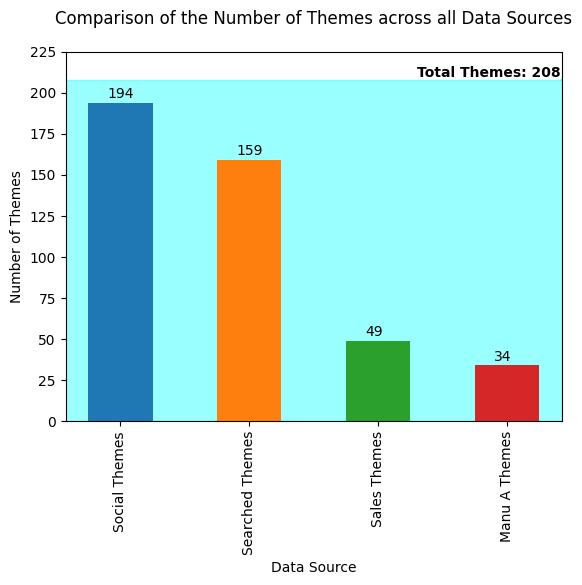

In [ ]:
#create subplots for easier configuration
fig, ax = plt.subplots()

#plot the total themes in theme_pl as a line
line = plt.axhline(themes, color='cyan', xmin=1, xmax=3.5)
#fill between the line and x-axis to have a background fill
plt.fill_between(np.arange(-0.5, 3.5, 0.01), [themes], 0, color='cyan', alpha=0.4, zorder=-1)

#create a dict with all answers from 2.1 to 2.5
graph = {'Social Themes': social_theme, 'Searched Themes': search_theme, 'Sales Themes': sales_theme, 'Manu A Themes': manu_theme}
bars = ax.bar(graph.keys(), graph.values(), width=0.5, color=sns.color_palette())

#annotation
#add number of total themes
ax.text(line.get_xdata()[-1] - 1.2, line.get_ydata()[-1], "Total Themes: " + str(themes), va='bottom', fontweight='semibold')
for bar in bars: #add the actual numbers on top of each bar
    yval = bar.get_height()
    ax.text(bar.get_x() - 0.1 + bar.get_width()/2, yval + 3, int(yval))
plt.xticks(rotation=90) #rotate for legibility
plt.title('Comparison of the Number of Themes across all Data Sources', pad=20)
plt.ylabel('Number of Themes')
plt.ylim(0, 225)
plt.xlabel('Data Source')
plt.show()

The number of total themes has been added as a background fill for readability and to highlight that the rest of the themes are part of it as well as their comparison.

## 3. Understand consumer preference (themes) available in each data source

###3.1 What are the top 5 themes preferred by consumers as per sales? (4 marks)

In [ ]:
#merge temp_sales and theme_pl on product_id and sort the result by dollar
#datetime object cannot be added; dropped
top_theme_by_dollar = sales.drop('date', axis=1).merge(theme_pl, on='product_id').groupby('theme_id').sum().sort_values(by='dollar', ascending=False).head(10).drop('product_id', axis=1).reset_index()
top_theme_by_dollar.head()

,theme_id,dollar,units,lbs
0,0,5.876714e+10,18581260352,59475593975
1,8,1.862566e+10,2627421936,6498709428
2,40,1.438821e+10,1559993572,5611153475
3,32,1.275780e+10,1391218733,5473048979
4,432,8.094533e+09,805116403,3516647524


In [ ]:
#merge again with theme_l df on theme_id to get the theme_name
top_dollar = top_theme_by_dollar.merge(theme_l, on='theme_id')
top_dollar.head(6)

,theme_id,dollar,units,lbs,theme_name
0,0,5.876714e+10,18581260352,59475593975,No Claim
1,8,1.862566e+10,2627421936,6498709428,low carb
2,40,1.438821e+10,1559993572,5611153475,no additives/preservatives
3,32,1.275780e+10,1391218733,5473048979,stroganoff
4,432,8.094533e+09,805116403,3516647524,apple cinnamon
5,186,7.007307e+09,378731037,4240180401,pollock


In [ ]:
print('In terms of sales dollar,')
print(f'The top 5 themes preferred by consumers as per sales: {top_dollar.theme_name[0:6].values}')
print(f'And their respective theme IDs are: {top_dollar.theme_id[0:6].values}')
#The Problem of No Claim
#Top 6 themes are shown as the top theme: No Claim is not useful for decision-making.

In terms of sales dollar,
The top 5 themes preferred by consumers as per sales: ['No Claim' 'low carb' 'no additives/preservatives' 'stroganoff'
 'apple cinnamon' 'pollock']
And their respective theme IDs are: [  0   8  40  32 432 186]


In [ ]:
top_units = top_dollar.sort_values(by='units', ascending=False)
top_units.head(6)

,theme_id,dollar,units,lbs,theme_name
0,0,5.876714e+10,18581260352,59475593975,No Claim
1,8,1.862566e+10,2627421936,6498709428,low carb
2,40,1.438821e+10,1559993572,5611153475,no additives/preservatives
3,32,1.275780e+10,1391218733,5473048979,stroganoff
4,432,8.094533e+09,805116403,3516647524,apple cinnamon
5,186,7.007307e+09,378731037,4240180401,pollock


In [ ]:
print('Somewhat logically, the above 5 themes are still the top preferred themes in terms of units sold.')

Somewhat logically, the above 5 themes are still the top preferred themes in terms of units sold.


###3.2 What are the top 5 themes preferred by consumers as per social media data? (4 marks)

In [ ]:
#drop the date, group by theme_id, add the total_post and sort by total_post
top_theme_by_social = social.drop('date', axis=1).groupby('theme_id').sum().sort_values(by='total_post', ascending=False).reset_index()
top_theme_by_social.head(6)

,theme_id,total_post
0,0,520029764
1,576,5329592
2,670,4609405
3,770,2821690
4,668,2462718
5,732,2417031


In [ ]:
#merge again with theme_l on theme_id to get the theme_name
top_social = top_theme_by_social.merge(theme_l, on='theme_id')
top_social.head(6)

,theme_id,total_post,theme_name
0,0,520029764,No Claim
1,576,5329592,health (passive)
2,670,4609405,boar
3,770,2821690,rabbit
4,668,2462718,probiotic
5,732,2417031,pumpkin


In [ ]:
print(f'The top 5 theme names preferred by consumers as per social media data are {top_social.theme_name[0:6].values}')
print(f'And their respective theme IDs are {top_social.theme_id[0:6].values}')
#The Problem of No Claim
#Top 6 themes are shown as the top theme: No Claim is not useful for decision-making.

The top 5 theme names preferred by consumers as per social media data are ['No Claim' 'health (passive)' 'boar' 'rabbit' 'probiotic' 'pumpkin']
And their respective theme IDs are [  0 576 670 770 668 732]


###3.3 What are the top 5 themes preferred by consumers based on the Google search data? (4 marks)

In [ ]:
#filter google_search from google by taking platform==google
google_search = search[search.platform=='google']
print(google_search.platform.unique()) #ensuring only google exists in google_search.platform
google_search.head()

['google']


,date,platform,search_volume,theme_id,week_number,year_new
0,2014-01-05,google,349,916,1,2014
1,2014-01-06,google,349,916,2,2014
2,2014-01-07,google,697,916,2,2014
3,2014-01-10,google,349,916,2,2014
4,2014-01-20,google,697,916,4,2014


In [ ]:
#drop unnecessary columns as only the search_volume column is interested
#group by theme_id, sum and sort by search_volume
top_theme_by_google = google_search.drop(columns=['date', 'platform', 'week_number', 'year_new']).groupby('theme_id').sum().sort_values(by='search_volume', ascending=False).reset_index()
top_theme_by_google.head()

,theme_id,search_volume
0,869,113482508
1,964,77498586
2,613,74104963
3,980,73600640
4,576,54400741


In [ ]:
#merge again with theme_l on theme_id to get the theme_name
top_google = top_theme_by_google.merge(theme_l, on='theme_id')
top_google.head(5)

,theme_id,search_volume,theme_name
0,869,113482508,ethical - environment
1,964,77498586,shrimp
2,613,74104963,sugar free
3,980,73600640,honey
4,576,54400741,health (passive)


In [ ]:
print(f'The top 5 theme names preferred by consumers based on the Google search data are {top_google.theme_name[0:5].values}')
print(f'And their respective theme IDs are {top_google.theme_id[0:5].values}')
#remember that google_search does not have any No Claim theme as stated in 2.3

The top 5 theme names preferred by consumers based on the Google search data are ['ethical - environment' 'shrimp' 'sugar free' 'honey' 'health (passive)']
And their respective theme IDs are [869 964 613 980 576]


###3.4 Show the results from 3.3 using graphs. (4 marks)

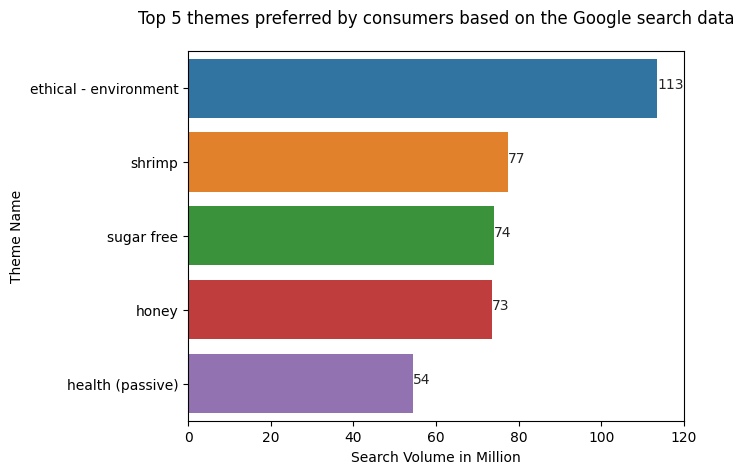

In [ ]:
fig, ax = plt.subplots()

#plot the horizontal bar
bars = sns.barplot(y='theme_name', x='search_volume', data=top_google[0:5], hue='theme_name', legend=False)

#annotation
plt.title('Top 5 themes preferred by consumers based on the Google search data', pad=20)
plt.xlabel('Search Volume in Million')
plt.xlim(0, 120000000)
plt.ylabel('Theme Name')
sns.set_style("darkgrid")

#format to million and add the digits next to the bar
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x)//1000000)))
for i in range(5):
    ax.text(top_google.search_volume[i], i, top_google.search_volume[i]//1000000)
plt.show()

## 4. Understand the trend of sales, social media, and Google search for the theme: GMO Free

###Pre-processing

In [ ]:
#find the theme_id of GMO free
theme_l[theme_l.theme_name == 'gmo free']

,theme_id,theme_name
16,81,gmo free


In [ ]:
#get the products with the theme_id 81 from theme_pl df
gmo_products = theme_pl[theme_pl.theme_id == 81].product_id.values

#get the sales data of gmo_products from sales df
#as the theme GMO Free is the main focus, product_id column is dropped
gmo_sales = sales[sales.product_id.isin(gmo_products)].groupby('date').sum().drop('product_id', axis=1)
#logical to say how many or less more units are sold due to social and search trends

print(gmo_sales.info())
gmo_sales.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 196 entries, 2016-01-09 to 2019-10-05
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   dollar  196 non-null    float64
 1   units   196 non-null    int64  
 2   lbs     196 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 6.1 KB
None


,dollar,units,lbs
date,,,
2016-01-09,19567288.0,1490241,7646740
2016-01-16,19539368.0,1514229,7606372
2016-01-23,19552112.0,1454022,7664131
2016-01-30,19844286.0,1497058,7639387
2016-02-06,19530176.0,1482319,7684994


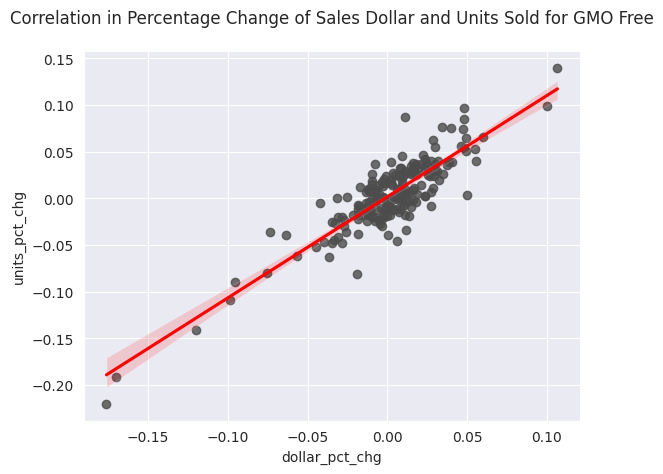

In [ ]:
#either sales dollar or units sold could be used for comparison with social and search data
#below is the proof for that assumption

#correlation of gmo_dollar and gmo_units df
corr_df = pd.DataFrame()

#pct_change of dollar and units is taken instead of the actual values to know the variation from the baseline as per Pearson's formula
corr_df['dollar_pct_chg'] = gmo_sales.dollar.pct_change()
corr_df['units_pct_chg'] = gmo_sales.units.pct_change()

#scatter plot to see the relation
sns.regplot(data=corr_df, x=corr_df.dollar_pct_chg, y=corr_df.units_pct_chg, color=".3", line_kws=dict(color="r"))
plt.title('Correlation in Percentage Change of Sales Dollar and Units Sold for GMO Free', pad=20)
plt.show()

In [ ]:
print(f'The correlation between sales dollar and units sold for GMO Free is {corr_df.dollar_pct_chg.corr(corr_df.units_pct_chg):.2f}.')
#a high correlation means one increases if another increases; if search trends drive up sales unit, sales dollar will see an upward trend as well.
#this is also true in Q3.1, where the top themes do not change order whether dollar or unit is considered
#implying that individual unit price has little impact on the total sales

The correlation between sales dollar and units sold for GMO Free is 0.88.


Since the correlation between sales dollar and units sold for GMO Free is 88%, either sales dollar or units sold could be used for comparison with social and search data. Units sold will be selected for this analysis as it is more logical to say how many or less more units are sold due to social and search trends.

In [ ]:
#only units column is considered for analysis
gmo_sales = gmo_sales['units']
gmo_sales.head()

date
2016-01-09    1490241
2016-01-16    1514229
2016-01-23    1454022
2016-01-30    1497058
2016-02-06    1482319
Name: units, dtype: int64

In [ ]:
#get the total_post series of gmo free with theme_id 81 from social df
gmo_social = social[social.theme_id == 81].groupby('date').sum()['total_post']
print(gmo_social.info())
gmo_social.head()

<class 'pandas.core.series.Series'>
DatetimeIndex: 1625 entries, 2015-05-21 to 2019-10-31
Series name: total_post
Non-Null Count  Dtype
--------------  -----
1625 non-null   int64
dtypes: int64(1)
memory usage: 25.4 KB
None


date
2015-05-21    23
2015-05-22    52
2015-05-23     9
2015-05-24    20
2015-05-25     7
Name: total_post, dtype: int64

In [ ]:
#get the google search_volume series of gmo free with theme_id 81 from social df
gmo_search = search[(search.platform == 'google') & (search.theme_id == 81)].groupby('date').sum()['search_volume']
print(gmo_search.info())
gmo_search.head()

<class 'pandas.core.series.Series'>
DatetimeIndex: 1972 entries, 2014-01-01 to 2019-10-01
Series name: search_volume
Non-Null Count  Dtype
--------------  -----
1972 non-null   int64
dtypes: int64(1)
memory usage: 30.8 KB
None


date
2014-01-01    1257
2014-01-02     718
2014-01-03     898
2014-01-04    1436
2014-01-05     898
Name: search_volume, dtype: int64

###4.1 Recommend the time granularity (Daily/Weekly/Monthly/Quarterly/Yearly). Please explain your rationale. (8 marks)

gmo_sales are recorded every 7 days, which is likely to be a weekly interval.

In [ ]:
#check the day name of all dates in gmo_sales
gmo_sales.index.get_level_values(0).day_name().value_counts()

date
Saturday    196
Name: count, dtype: int64

As expected, the sales entries are recorded every Saturday, compiling all the sales information of each type of product sold during the week together at the end of the week.

In [ ]:
#To elaborate,
sales.duplicated(subset=['date', 'product_id']).sum()

0

0 means there is no duplicated entry with the exact same date and product_id, i.e., either each product was sold exactly once every week, or the total amount of dollar, units and lbs of a product sold during the week is complied and recorded as a single entry at the end of every week on Sat. The latter is logical, and thus a weekly granularity is suitable for the sales data as it fits the given dataset exactly.

In [ ]:
#for gmo_social
gmo_social.reindex #refill any date that is skipped
gmo_social.isnull().sum() #if a date is filled, there will be a null entry with the new date

0

It seems gmo_social has a daily record with no missing enrty from 2015-05-21 to 2019-10-31.

In [ ]:
#doing the same for gmo_search
gmo_search.reindex
gmo_search.isnull().sum()

0

Both gmo_social and gmo_search are recorded on a daily basis without missing a single day, and thus any time granularity would be fine. But, to analyze gmo_sales alongside gmo_social and gmo_search, using the same time granularity of weekly would be most logical and effective. In addition, most google_search and social_media trends in real life rarely last longer than one week. Thus, claiming a product increased or decreased in sales in a month or a quarter due to a social media trend that lasted a week would be illogical. There is not enough sales data to do daily granularity, and yearly gradularity will result in a very high aggregation. Therefore, **weekly time granularity** is recommended for all three datasets.

###4.2 Use the recommended time granularity, analyze the time series trend among the sales, social media, and Google search data for the following theme and show if there is any correlation among the sales, social media, and Google search data for the theme assigned:
Student C: GMO free (8 marks)

In [ ]:
#changing the time freq to weekly-saturday
gmo_sales_weekly = gmo_sales.resample('W-SAT').sum()
print('\nGMO Weekly Sales Units')
print(gmo_sales_weekly.head())
gmo_social_weekly = gmo_social.resample('W-SAT').sum()
print('\nGMO Weekly Social Posts')
print(gmo_social_weekly.head())
gmo_search_weekly = gmo_search.resample('W-SAT').sum()
print('\nGMO Weekly Search Volume')
print(gmo_search_weekly.head())


GMO Weekly Sales Units
date
2016-01-09    1490241
2016-01-16    1514229
2016-01-23    1454022
2016-01-30    1497058
2016-02-06    1482319
Freq: W-SAT, Name: units, dtype: int64

GMO Weekly Social Posts
date
2015-05-23     84
2015-05-30    236
2015-06-06    355
2015-06-13    167
2015-06-20    250
Freq: W-SAT, Name: total_post, dtype: int64

GMO Weekly Search Volume
date
2014-01-04    4309
2014-01-11    6284
2014-01-18    4311
2014-01-25    8976
2014-02-01    6105
Freq: W-SAT, Name: search_volume, dtype: int64


In [ ]:
#combine the three series
#inner join ensures that only entries that have non-null values in all three columns are taken
gmo = pd.concat([gmo_sales_weekly, gmo_social_weekly, gmo_search_weekly], axis=1, join='inner')
gmo.columns = ['units', 'total_post', 'search_volume']
assert gmo.isnull().sum().sum() == 0 #ensuring there are no null values
gmo.head()

,units,total_post,search_volume
date,,,
2016-01-09,1490241,228,5926
2016-01-16,1514229,382,3592
2016-01-23,1454022,504,6642
2016-01-30,1497058,389,9155
2016-02-06,1482319,288,7002


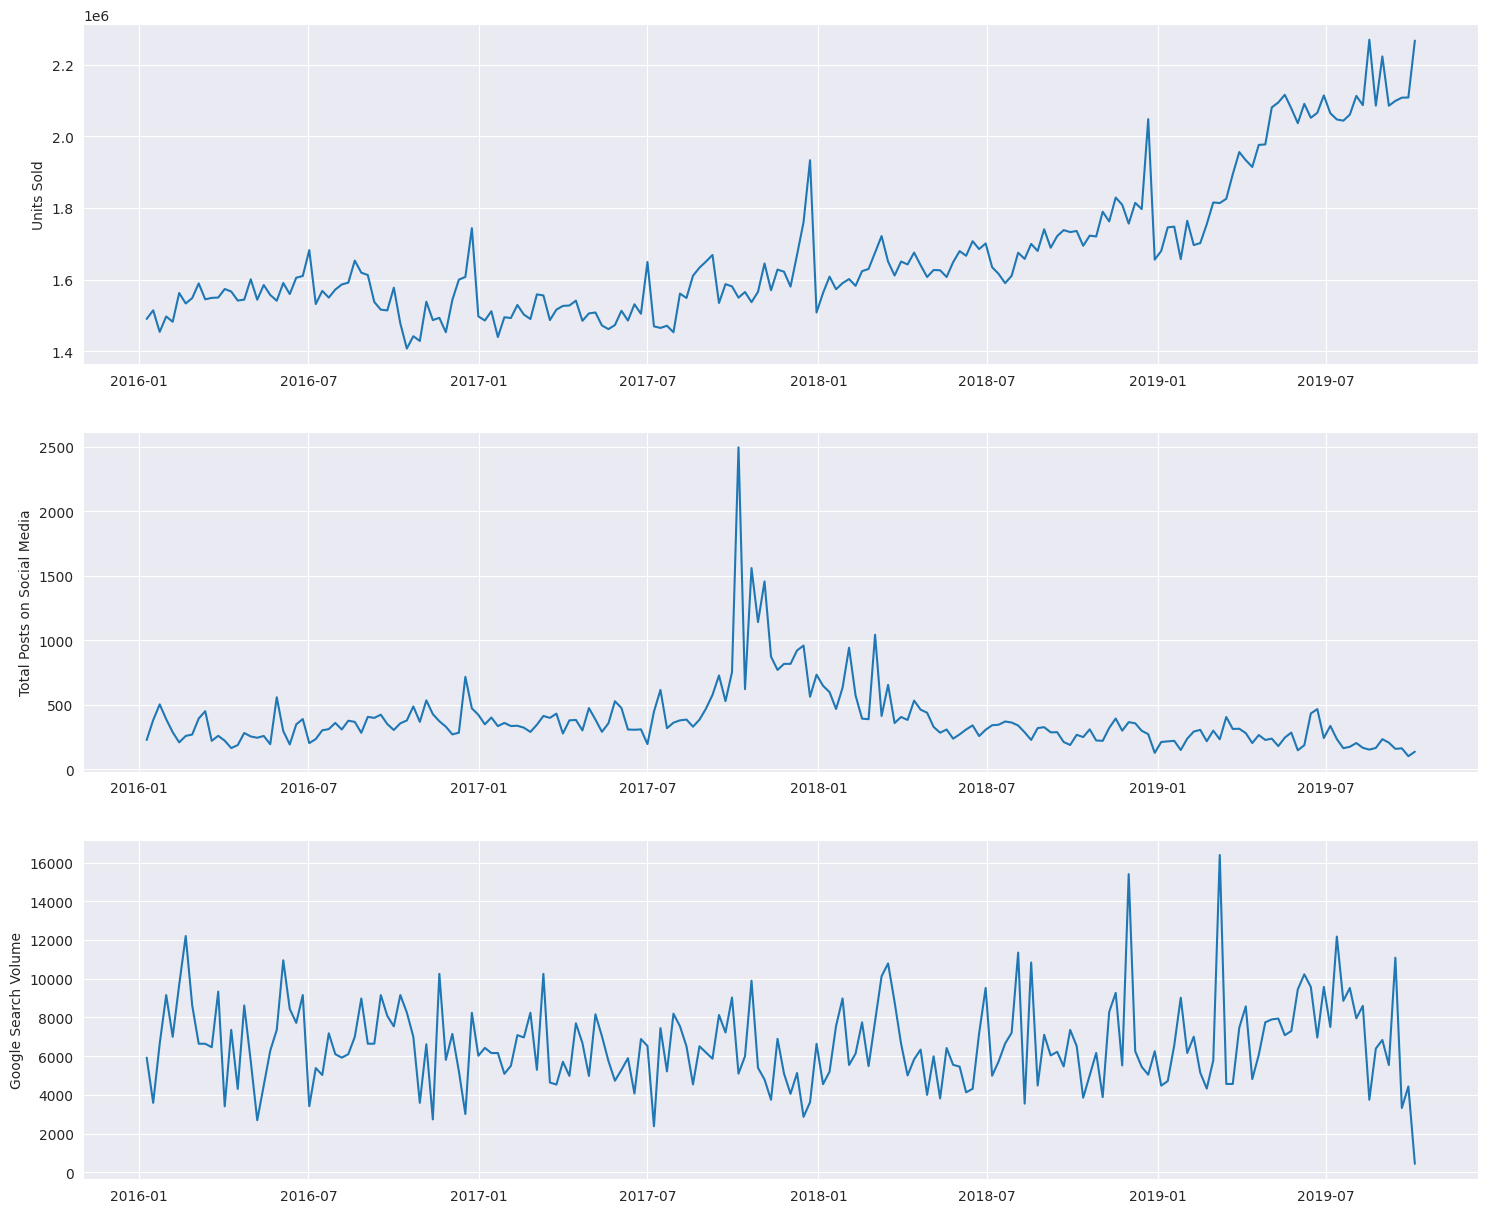

In [ ]:
#explore trends
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(18, 15))
ax1.plot(gmo.index, gmo.units)
ax1.set_ylabel('Units Sold')
ax2.plot(gmo.index, gmo.total_post)
ax2.set_ylabel('Total Posts on Social Media')
ax3.plot(gmo.index, gmo.search_volume)
ax3.set_ylabel('Google Search Volume')
plt.show()

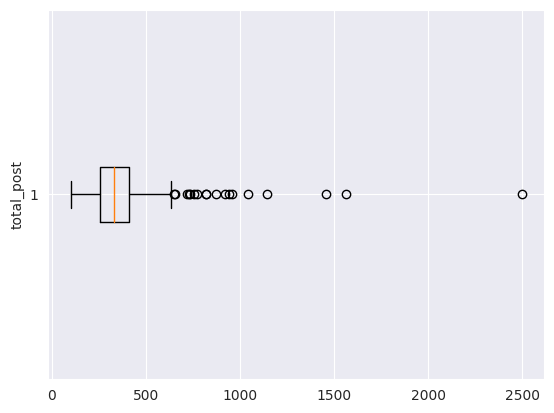

In [ ]:
#units and search_volume trends look normal
#total_post has huge spikes around 2017 Oct, Dec, which can skew the data in normalization

#visualize outliers with a boxplot
plt.boxplot(gmo.total_post, vert=False)
plt.ylabel('total_post')
plt.show()

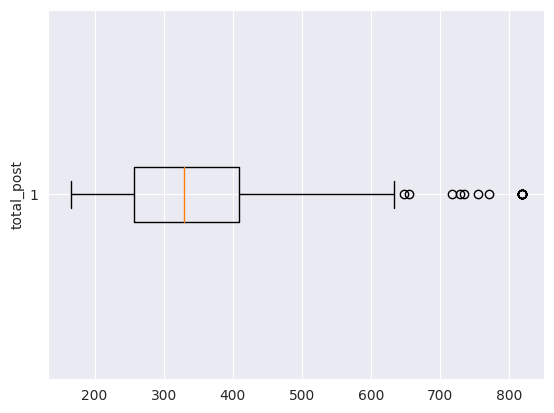

In [ ]:
#cap total_post for huge numbers within 0.95 percentile
gmo['total_post'] = gmo.total_post.clip(gmo.total_post.quantile(0.05), gmo.total_post.quantile(0.95))
gmo['search_volume'] = gmo.search_volume.clip(gmo.search_volume.quantile(0.05), gmo.search_volume.quantile(0.95))

#confirmation
plt.boxplot(gmo.total_post, vert=False)
plt.ylabel('total_post')
plt.show()

In [ ]:
#normalize the columns in gmo to get a better view of all three trends together

normalized_gmo = pd.DataFrame()

#units sold will be normalized based on the starting value, which is the number of units sold in the first week
#so that the percentage change relative to the original value can be visualized
normalized_gmo['units'] = gmo.units.div(gmo.units.iloc[0]).mul(100)

#total_post and search_volume will be applied with z-score normalization to understand how they deviate from the mean value
normalized_gmo['total_post'] = stats.zscore(gmo.total_post).mul(100).add(100)
normalized_gmo['search_volume'] = stats.zscore(gmo.search_volume).mul(100).add(100)

normalized_gmo.head()

,units,total_post,search_volume
date,,,
2016-01-09,100.000000,15.930522,65.760916
2016-01-16,101.609673,108.757077,-58.711798
2016-01-23,97.569588,182.294997,103.945347
2016-01-30,100.457443,112.976466,237.964169
2016-02-06,99.468408,52.096712,123.144223


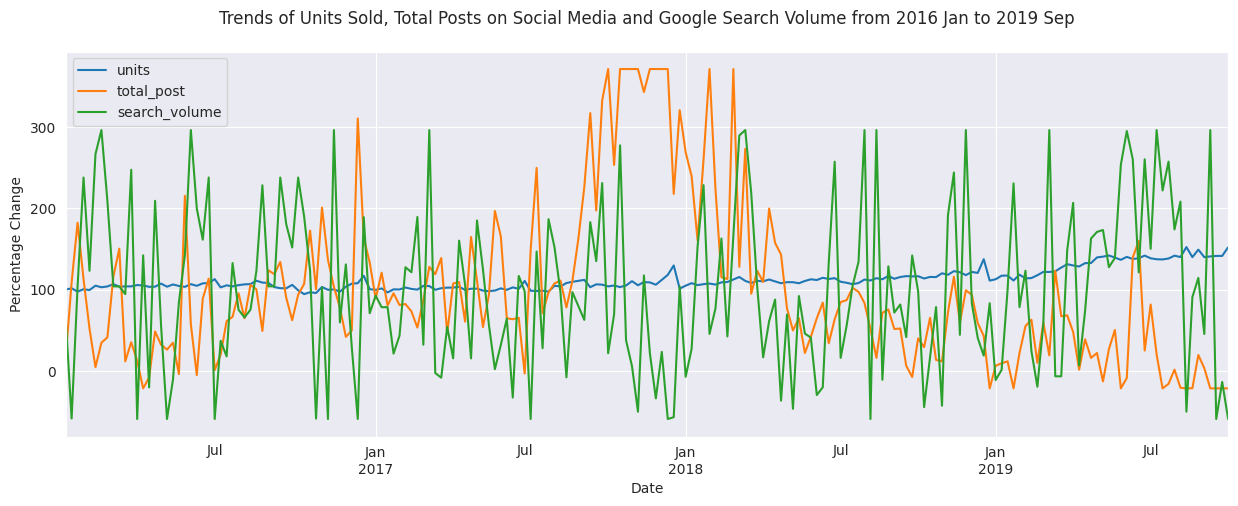

In [ ]:
#plot
normalized_gmo.plot(figsize=(15, 5))

#annotate
plt.xlabel('Date')
plt.ylabel('Percentage Change')
plt.title('Trends of Units Sold, Total Posts on Social Media and Google Search Volume from 2016 Jan to 2019 Sep', pad=20)
plt.legend(loc='upper left')

plt.show()

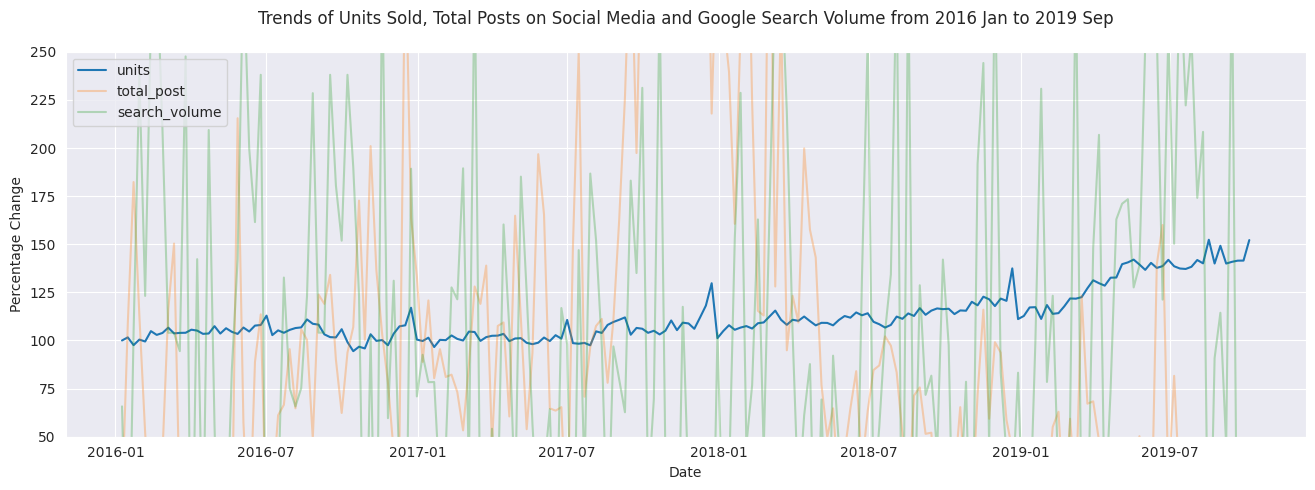

In [ ]:
#total_post has a very huge outlier around 2017 Sep, Oct
#let us focus near the bottom part from 50% to 250% change

#redraw
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(normalized_gmo.index, normalized_gmo.units, label='units')
ax.plot(normalized_gmo.index, normalized_gmo.total_post, alpha=0.3, label='total_post')
ax.plot(normalized_gmo.index, normalized_gmo.search_volume, alpha=0.3, label='search_volume')

#annotate
plt.xlabel('Date')
plt.ylabel('Percentage Change')
plt.title('Trends of Units Sold, Total Posts on Social Media and Google Search Volume from 2016 Jan to 2019 Sep', pad=20)
ax.set_ylim(50, 250)
plt.legend(loc='upper left')

plt.show()

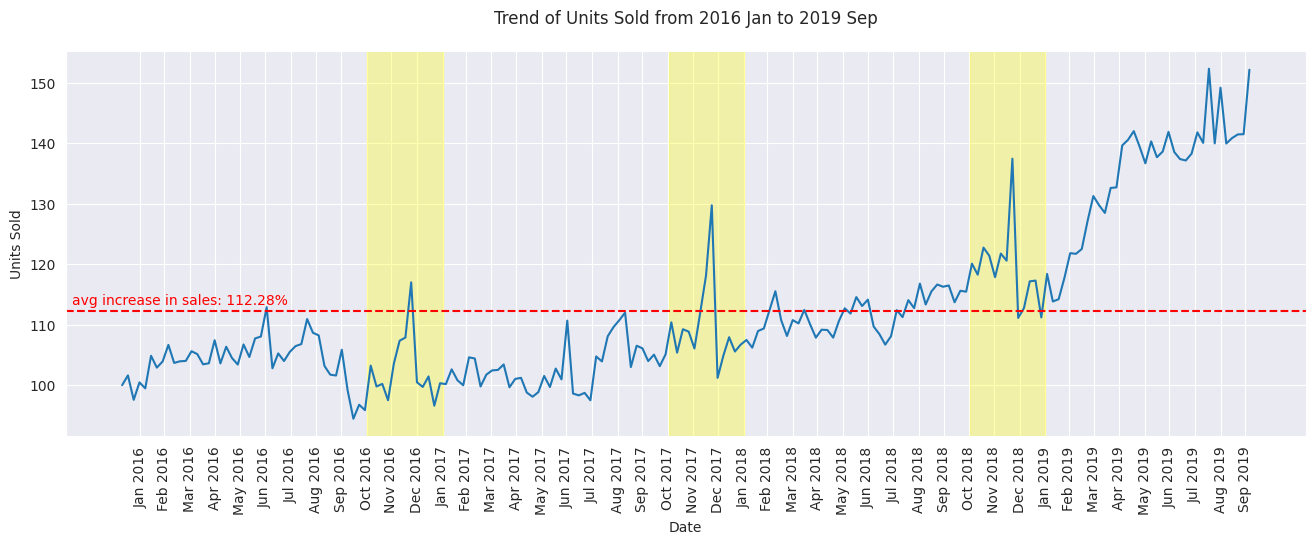

In [ ]:
#too messy to see sales units; let us focus on units sold
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(normalized_gmo.index, normalized_gmo.units)

#create a datetime series to properly annotate x ticks
index = pd.date_range(start=normalized_gmo.index[0], end=normalized_gmo.index[-1], freq='M')
plt.xticks(list(index), rotation=90)
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%b %Y'))

#add the average line
ax.axhline(normalized_gmo.units.mean(), color='r', linestyle='--')

#highlight some periods; refer the text after the graph
for year in range(2016, 2019):
    plt.axvspan(pd.Timestamp(f'{year}-11-01'), pd.Timestamp(f'{year+1}-01-31'), color='yellow', alpha=0.3)

#annotate
plt.text(normalized_gmo.index[0]-pd.DateOffset(months=2), normalized_gmo.units.mean()+1, f'avg increase in sales: {normalized_gmo.units.mean():.2f}%', color='red')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.title('Trend of Units Sold from 2016 Jan to 2019 Sep', pad=20)

plt.show()

**Analysis Results**

From the two graphs, it can be seen that
*   the sales of GMO Free theme noticeably increased (~50%) over the three years.
*   the total posts on social media and the search volume on Google flatucate a lot, sometimes together, with irregular spikes.
*   the sales trend spikes towards the end of Dec every year.
*   no noticeable pattern is seen for Google search and social media trends



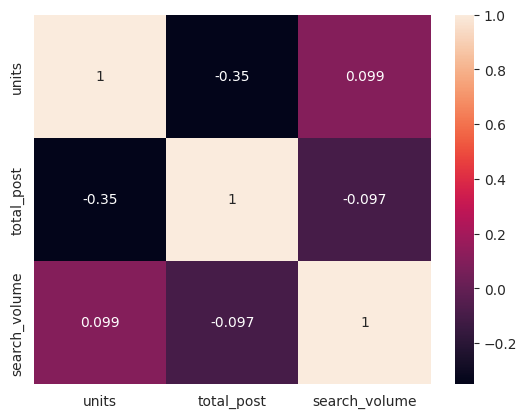

In [ ]:
#correlation analysis
sns.heatmap(normalized_gmo.corr(), annot=True)
plt.show()

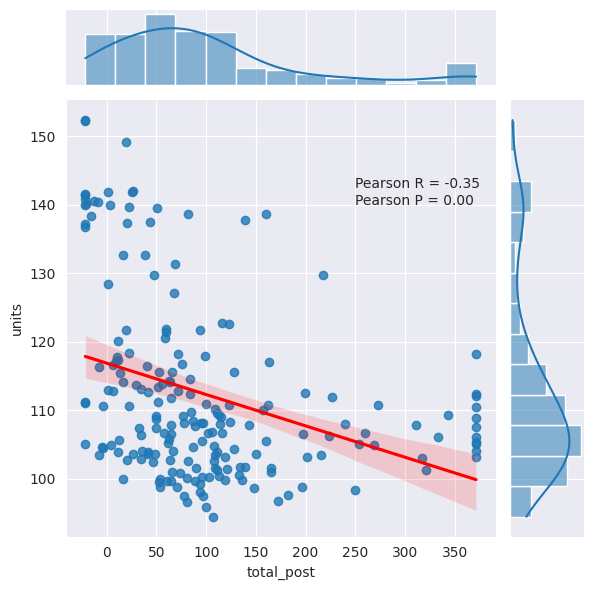

In [ ]:
#the overall statistics do not look very promising
#let us visualize this

#units vs total_post correlation
corr = stats.pearsonr(normalized_gmo.total_post, normalized_gmo.units)
#scattered joint plot with linear reg line and distribution charts
sns.jointplot(x='total_post', y='units', data=normalized_gmo, kind='reg', line_kws=dict(color="r"))
#add numbers for clarity
plt.text(250, 140, f'Pearson R = {corr[0]:.2f}\nPearson P = {corr[1]:.2f}')
plt.show()

As shown above, the units sold and social media posts have a very small negative correlation of -0.27. This correlation is very weak to accurately say one is related to the other, but Manufacturer A should look into this matter as the correlation is negative, implying that the posts on social media may have negative sentiment towards GMO Free.

In [ ]:
#a good point to note is the given social media data does not mention any sentiment of the posts about the product, which is a crucial metric in analyzing social media trends
#this also questions the meaning of the word 'preferred' in Q3.2; whether to assume the posts have positive or negative sentiment towards the product in general

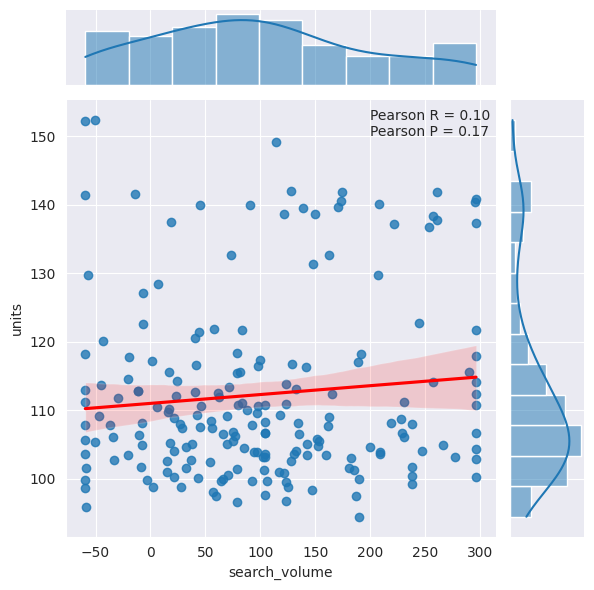

In [ ]:
#do the same for units vs search_volume
corr = stats.pearsonr(normalized_gmo.search_volume, normalized_gmo.units)
sns.jointplot(x='search_volume', y='units', data=normalized_gmo, kind='reg', line_kws=dict(color="r"))
plt.text(200, 150, f'Pearson R = {corr[0]:.2f}\nPearson P = {corr[1]:.2f}')
plt.show()

From the graph, it is seen that not only is the correlation very low (r=0.09), but the statistically importance, r, is 0.21 (>0.05), indicating that there is no significant linear relationship between units sold and google search volume.

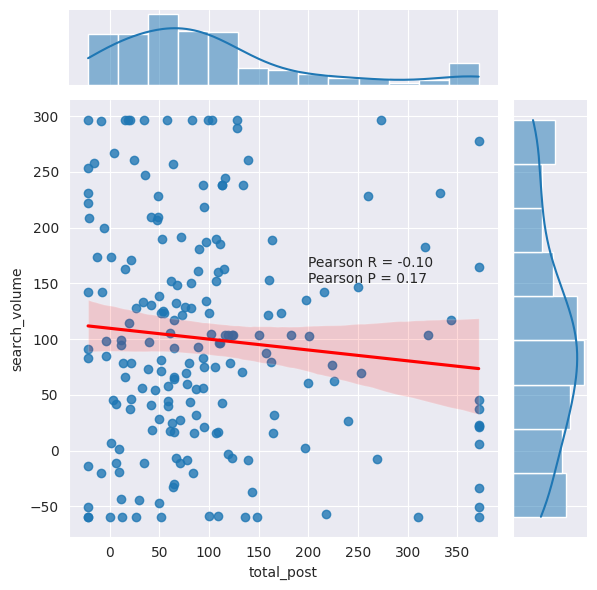

In [ ]:
#do the same for total_post vs search_volume
corr = stats.pearsonr(normalized_gmo.total_post, normalized_gmo.search_volume)
sns.jointplot(x='total_post', y='search_volume', data=normalized_gmo, kind='reg', line_kws=dict(color="r"))
plt.text(200, 150, f'Pearson R = {corr[0]:.2f}\nPearson P = {corr[1]:.2f}')
plt.show()

The result is similar to the previous one of search_volume vs units correlation; Pearson R is too big to statistically say more posts on social media make people search the theme more frequently.

In [ ]:
#let us focus on oct-to-jan period of each year to find out whether the regular spike in sales relate to social media or google search, or it is purely a seasonal spike

#create a function to draw the graph three times for three years
def focused_correlation(start_date, end_date):
  #data
  data = normalized_gmo.loc[start_date:end_date]
  index = data.index

  fig, ax1 = plt.subplots(figsize=(16, 5))

  #plot untis sold as main
  color = 'tab:red'
  ax1.set_xlabel('Date')
  ax1.set_ylabel('% Change')
  p1, = ax1.plot(index, data.units, color=color, label='Units Sold')
  ax1.tick_params(axis='y', labelcolor=color)

  #used two y axes as the variation diff is too large to be plotted together
  #plot total_post and search volume with shared x-axis
  ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

  p2, = ax2.plot(index, data.total_post, label='Social Media Posts', alpha=0.4)
  p3, = ax2.plot(index, data.search_volume, label='Google Search Volume', alpha=0.4)

  #create a datetime series to properly annotate x ticks
  index = pd.date_range(start=index[0], end=index[-1], freq='W-SAT')
  ax1.tick_params(axis='x', labelrotation=45)
  ax1.set_xticks(list(index))
  ax1.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%Y %b %d'))

  fig.tight_layout()  # otherwise the right y-label is slightly clipped
  ax1.legend(handles=[p1, p2, p3])
  plt.title(f'Sales Trend alongside Social Media & Google Search Trends from {start_date} to {end_date}', pad=20)

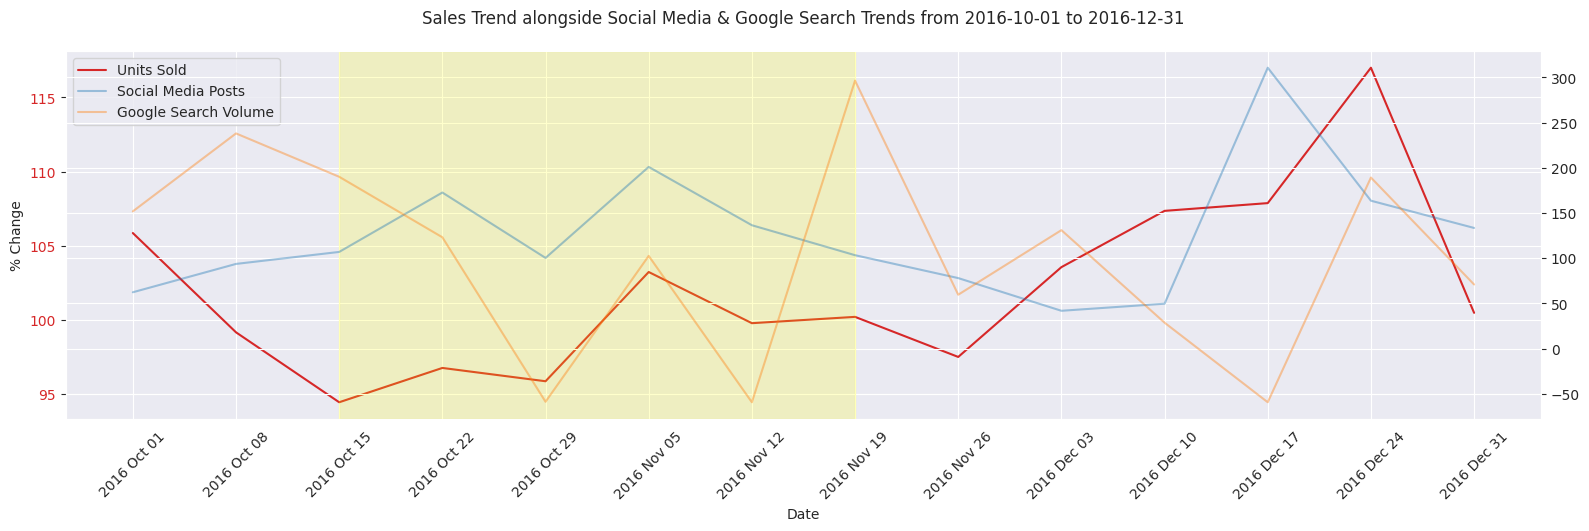

In [ ]:
focused_correlation('2016-10-01', '2016-12-31')
#highlight
plt.axvspan(pd.Timestamp(f'2016-10-15'), pd.Timestamp(f'2016-11-19'), color='yellow', alpha=0.2)
plt.show()

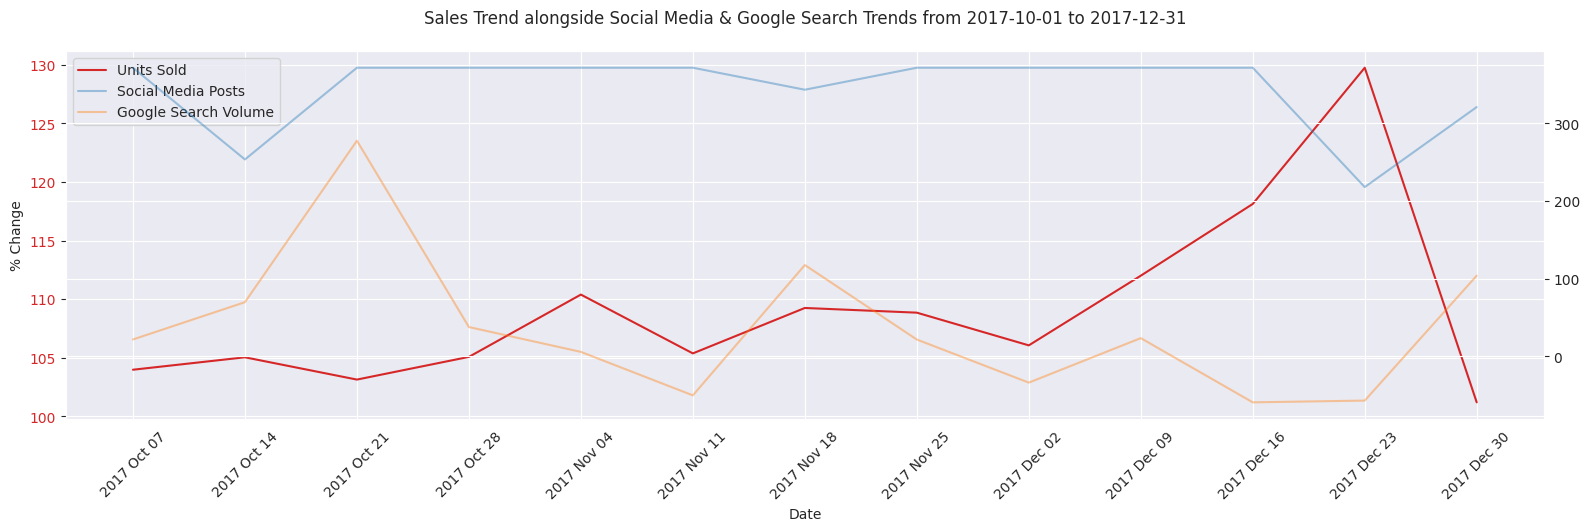

In [ ]:
focused_correlation('2017-10-01', '2017-12-31')
plt.show()

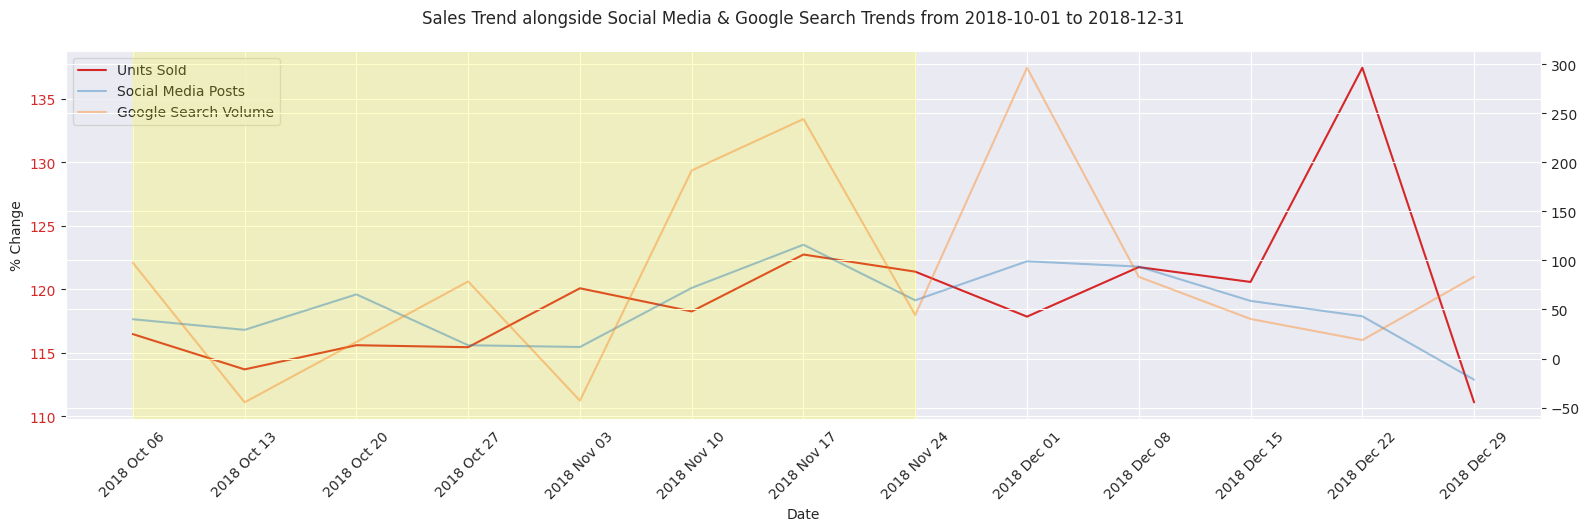

In [ ]:
focused_correlation('2018-10-01', '2018-12-31')
#highlight
plt.axvspan(pd.Timestamp(f'2018-10-06'), pd.Timestamp(f'2018-11-24'), color='yellow', alpha=0.2)
plt.show()

Correlation Conclusion
*   Statistically, there is no strong correlation for sales, social and search trends over the three years.
*   Visually, there were some period where one seemed to correlate to the other
 *  Sales and Social Media trends from 2016 Oct 15 to 2016 Nov 19 and 2018 Oct 6 to 2018 Nov 27
*   The regular spikes in sales towards the end of each year, around Dec, is believed to a seasonal spike, rather than it being caused by social media posts or Google search volume



## 5. Understand the overall market share in sales of our client Manufacturer A; Student C

###5.1 Show the total sales unit of various vendors. (4 marks)

In [ ]:
#drop date column from sales df as .sum() does not work on dates
#merge sales and manu df on product_id
#groupby vendor name
#sum and sort by decending units
#drop all columns except vendor and units
#reset index
top_manu = sales.drop('date', axis=1).merge(manu, on='product_id').groupby('vendor').sum().sort_values(by='units', ascending=False).drop(columns=['dollar', 'lbs', 'product_id']).reset_index()
#rename the column for clarity
top_manu.rename(columns={'units': 'total_units'}, inplace=True)
print('The total sales unit of various vendors are: ')
top_manu

The total sales unit of various vendors are: 


,vendor,total_units
0,A,11110417674
1,B,3841860718
2,D,2582299912
3,Others,2421832452
4,Private Label,2197710799
5,F,525090112
6,H,294479885
7,E,200362303
8,G,181286878


###5.2 Who are the top 3 manufacturers in overall sales unit? (4 marks)

In [ ]:
print('The top 3 manufacturers in overall sales unit are: ')
for i in range(3):
  print(f'{i+1}. Vendor {top_manu.vendor[i]} with total sales of {top_manu.total_units[i]/1e+9:.3f} billion units.')

The top 3 manufacturers in overall sales unit are: 
1. Vendor A with total sales of 11.110 billion units.
2. Vendor B with total sales of 3.842 billion units.
3. Vendor D with total sales of 2.582 billion units.


###5.3 Plot the percentage distribution of market shares in terms of sales unit value among all vendors in a graph. (4 marks)

In [ ]:
#calculate each percent as a fraction of sum of total_units across all vendors
top_manu['pct'] = top_manu.total_units.div(top_manu.total_units.sum()).mul(100)
top_manu.pct = top_manu.pct.round(2)
top_manu

,vendor,total_units,pct
0,A,11110417674,47.57
1,B,3841860718,16.45
2,D,2582299912,11.06
3,Others,2421832452,10.37
4,Private Label,2197710799,9.41
5,F,525090112,2.25
6,H,294479885,1.26
7,E,200362303,0.86
8,G,181286878,0.78


In [ ]:
#create a separate df with vendors that have low pct as minors
# copy = top_manu[:]
minors = top_manu.copy().iloc[5:] #vendor F to G

#calculate the pct among minors themselves
minors['pct2'] = round(minors.pct.div(minors.pct.sum()).mul(100), 2)

#reset the index
minors.reset_index(drop=True, inplace=True)

minors

,vendor,total_units,pct,pct2
0,F,525090112,2.25,43.69
1,H,294479885,1.26,24.47
2,E,200362303,0.86,16.70
3,G,181286878,0.78,15.15


In [ ]:
#the previous minors df is to draw a bar graph on the left as the pie chart is too big to accurately depict tiny market shares for vendor F, H, E and G
#minors df can be concatenated to top_manu after deleting F,H,E,G from the list

# #here, another appraoch will be used
top_manu.vendor.iloc[5:] = 'Minors' #rename F,H,E,G to minors
vendors = top_manu.groupby('vendor', as_index=False).sum().sort_values(by='total_units', ascending=True, ignore_index=True) #grouping by vendor and summing adds up F,H,E,G as Minors
vendors

,vendor,total_units,pct
0,Minors,1201219178,5.15
1,Private Label,2197710799,9.41
2,Others,2421832452,10.37
3,D,2582299912,11.06
4,B,3841860718,16.45
5,A,11110417674,47.57


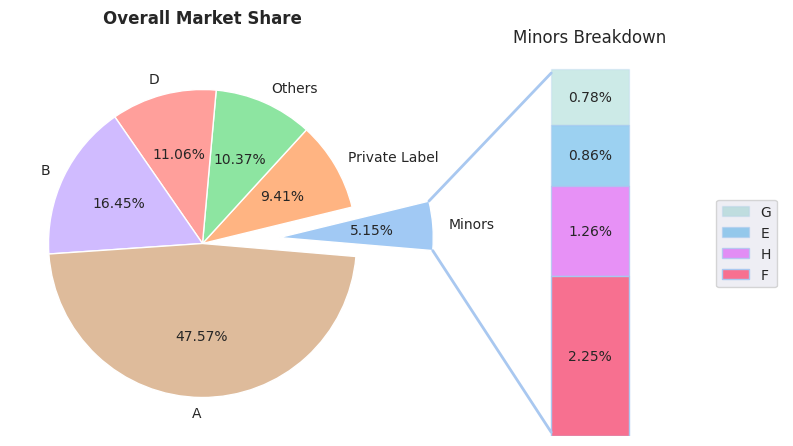

In [ ]:
#example code from matplotlib with some customization

from matplotlib.patches import ConnectionPatch

# make figure and assign axis objects
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.subplots_adjust(wspace=0)

# pie chart parameters
explode = [0.5, 0, 0, 0, 0, 0]
# rotate so that first wedge is split by the x-axis
angle = vendors.pct[0] - 10
wedges, text, *_ = ax1.pie(vendors.pct, autopct='%1.2f%%', startangle=angle,
                     labels=vendors.vendor, explode=explode, colors=sns.color_palette('pastel'))

# text labels
ax1.set_title('Overall Market Share', fontweight='semibold', pad=20)

# bar chart parameters
pct = minors.pct2.tolist()
name = minors.vendor.tolist()
original = list(reversed(minors.pct.tolist()))
bottom = 1
width = .2

# # Adding from the top matches the legend.
for j, (height, label) in enumerate(reversed([*zip(pct, name)])):
  bottom -= height
  bc = ax2.bar(0, height, width, bottom=bottom, color=sns.husl_palette(h=.5)[j], label=label,
                alpha= 0.25 + 0.25 * j, edgecolor=[0.6627, 0.7843, 0.9412])
  ax2.bar_label(bc, labels=[f"{original[j]}%"], label_type='center')

ax2.set_title('Minors Breakdown')
ax2.legend(loc='center right')
ax2.axis('off')
ax2.set_xlim(- 2.5 * width, 2.5 * width)

# use ConnectionPatch to draw lines between the two plots
theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center, r = wedges[0].center, wedges[0].r

# draw top connecting line
x = r * np.cos(np.pi / 180 * theta2) + center[0]
y = r * np.sin(np.pi / 180 * theta2) + center[1]
con = ConnectionPatch(xyA=(-width / 2, 0), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color([0.6627, 0.7843, 0.9412])
con.set_linewidth(2)
ax2.add_artist(con)

# draw bottom connecting line
x = r * np.cos(np.pi / 180 * theta1) + center[0]
y = r * np.sin(np.pi / 180 * theta1) + center[1]
con = ConnectionPatch(xyA=(-width / 2, -98), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color([0.6627, 0.7843, 0.9412])
ax2.add_artist(con)
con.set_linewidth(2)

plt.show()

## 6. Find the potential competitors for our client Manufacturer A in the theme assigned: Student C: GMO free (8 marks)

In [ ]:
#bring back gmo_sales from Q4 with product_id
#fyi: gmo_products is the list of product_id that has theme_id 81-GMO Free
gmo_sales = sales[sales.product_id.isin(gmo_products)].drop('date', axis=1).reset_index(drop=True)
gmo_sales.head()
#this gives the sales info of all products that are of GMO Free theme

,product_id,dollar,units,lbs
0,23407,45418.0,2072,12173
1,23411,8866.0,718,2108
2,23611,6412.0,372,1117
3,23684,3285.0,1868,350
4,23685,3072.0,1738,326


In [ ]:
gmo_manu = gmo_sales.merge(manu, on='product_id').groupby('vendor').sum().sort_values(by='dollar', ascending=False).drop(columns=['product_id'])
gmo_manu

,dollar,units,lbs
vendor,,,
F,2.474393e+09,213726919,859236294
Others,1.344401e+09,104579286,612899003
A,2.263205e+07,7954487,12833029
B,1.626059e+07,1551217,6465534
Private Label,1.181499e+06,89335,690307
H,5.916570e+05,51215,165994


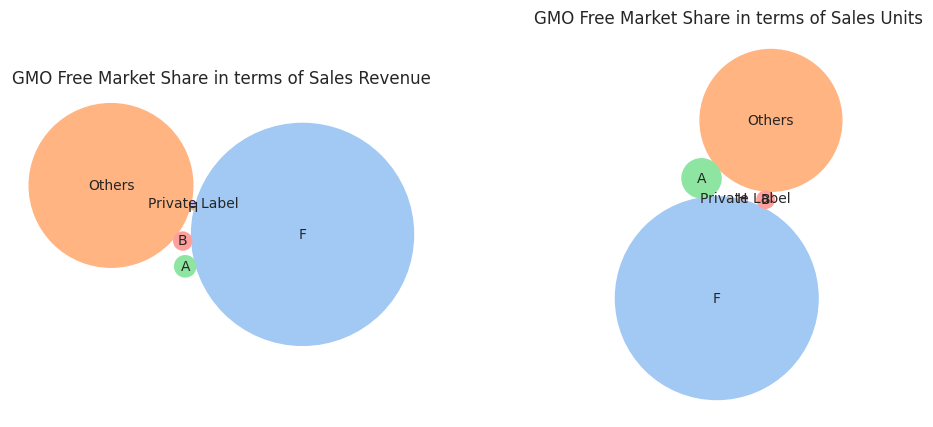

In [ ]:
#matplotlib example code

class BubbleChart:
    def __init__(self, area, bubble_spacing=0):
        """
        Setup for bubble collapse.

        Parameters
        ----------
        area : array-like
            Area of the bubbles.
        bubble_spacing : float, default: 0
            Minimal spacing between bubbles after collapsing.

        Notes
        -----
        If "area" is sorted, the results might look weird.
        """
        area = np.asarray(area)
        r = np.sqrt(area / np.pi)

        self.bubble_spacing = bubble_spacing
        self.bubbles = np.ones((len(area), 4))
        self.bubbles[:, 2] = r
        self.bubbles[:, 3] = area
        self.maxstep = 2 * self.bubbles[:, 2].max() + self.bubble_spacing
        self.step_dist = self.maxstep / 2

        # calculate initial grid layout for bubbles
        length = np.ceil(np.sqrt(len(self.bubbles)))
        grid = np.arange(length) * self.maxstep
        gx, gy = np.meshgrid(grid, grid)
        self.bubbles[:, 0] = gx.flatten()[:len(self.bubbles)]
        self.bubbles[:, 1] = gy.flatten()[:len(self.bubbles)]

        self.com = self.center_of_mass()

    def center_of_mass(self):
        return np.average(
            self.bubbles[:, :2], axis=0, weights=self.bubbles[:, 3]
        )

    def center_distance(self, bubble, bubbles):
        return np.hypot(bubble[0] - bubbles[:, 0],
                        bubble[1] - bubbles[:, 1])

    def outline_distance(self, bubble, bubbles):
        center_distance = self.center_distance(bubble, bubbles)
        return center_distance - bubble[2] - \
            bubbles[:, 2] - self.bubble_spacing

    def check_collisions(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return len(distance[distance < 0])

    def collides_with(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return np.argmin(distance, keepdims=True)

    def collapse(self, n_iterations=50):
        """
        Move bubbles to the center of mass.

        Parameters
        ----------
        n_iterations : int, default: 50
            Number of moves to perform.
        """
        for _i in range(n_iterations):
            moves = 0
            for i in range(len(self.bubbles)):
                rest_bub = np.delete(self.bubbles, i, 0)
                # try to move directly towards the center of mass
                # direction vector from bubble to the center of mass
                dir_vec = self.com - self.bubbles[i, :2]

                # shorten direction vector to have length of 1
                dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))

                # calculate new bubble position
                new_point = self.bubbles[i, :2] + dir_vec * self.step_dist
                new_bubble = np.append(new_point, self.bubbles[i, 2:4])

                # check whether new bubble collides with other bubbles
                if not self.check_collisions(new_bubble, rest_bub):
                    self.bubbles[i, :] = new_bubble
                    self.com = self.center_of_mass()
                    moves += 1
                else:
                    # try to move around a bubble that you collide with
                    # find colliding bubble
                    for colliding in self.collides_with(new_bubble, rest_bub):
                        # calculate direction vector
                        dir_vec = rest_bub[colliding, :2] - self.bubbles[i, :2]
                        dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                        # calculate orthogonal vector
                        orth = np.array([dir_vec[1], -dir_vec[0]])
                        # test which direction to go
                        new_point1 = (self.bubbles[i, :2] + orth *
                                      self.step_dist)
                        new_point2 = (self.bubbles[i, :2] - orth *
                                      self.step_dist)
                        dist1 = self.center_distance(
                            self.com, np.array([new_point1]))
                        dist2 = self.center_distance(
                            self.com, np.array([new_point2]))
                        new_point = new_point1 if dist1 < dist2 else new_point2
                        new_bubble = np.append(new_point, self.bubbles[i, 2:4])
                        if not self.check_collisions(new_bubble, rest_bub):
                            self.bubbles[i, :] = new_bubble
                            self.com = self.center_of_mass()

            if moves / len(self.bubbles) < 0.1:
                self.step_dist = self.step_dist / 2

    def plot(self, ax, labels, colors):
        """
        Draw the bubble plot.

        Parameters
        ----------
        ax : matplotlib.axes.Axes
        labels : list
            Labels of the bubbles.
        colors : list
            Colors of the bubbles.
        """
        for i in range(len(self.bubbles)):
            circ = plt.Circle(
                self.bubbles[i, :2], self.bubbles[i, 2], color=colors[i])
            ax.add_patch(circ)
            ax.text(*self.bubbles[i, :2], labels[i],
                    horizontalalignment='center', verticalalignment='center')

def compare_gmo_sales():
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), subplot_kw=dict(aspect="equal"))

  bubble_chart = BubbleChart(area=gmo_manu.dollar, bubble_spacing=0.1)
  bubble_chart.collapse()
  bubble_chart.plot(ax1, gmo_manu.index, sns.color_palette("pastel"))
  ax1.axis("off")
  ax1.relim()
  ax1.autoscale_view()
  ax1.set_title(f'GMO Free Market Share in terms of Sales Revenue')

  bubble_chart = BubbleChart(area=gmo_manu.units, bubble_spacing=0.1)
  bubble_chart.collapse()
  bubble_chart.plot(ax2, gmo_manu.index, sns.color_palette("pastel"))
  ax2.axis("off")
  ax2.relim()
  ax2.autoscale_view()
  ax2.set_title(f'GMO Free Market Share in terms of Sales Units')

  plt.show()

compare_gmo_sales()

In terms of total sales dollar and units, for GMO Free theme, it seems 'Manufacture F' and 'Others' are the two giants that 'Manufacturer A' should aim to catch up in the near future, rather than competing and be the shrimp between two whales.

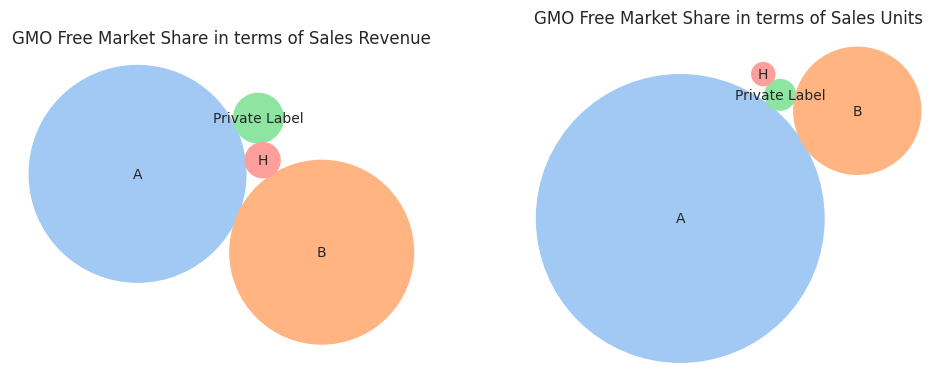

In [ ]:
#F and others are dropped as they are too big to be compared with the rest
gmo_manu.drop(['F', 'Others'], inplace=True)
compare_gmo_sales()

In [ ]:
print("In terms of overall sales data,")
print(f'Manufacturer B is the most potential competitor for Manufacturer A in GMO Free theme.')
diff_dollar = gmo_manu.loc['A'].dollar - gmo_manu.loc['B'].dollar
diff_units = gmo_manu.loc['A'].units - gmo_manu.loc['B'].units
print(f"Manufacturer B sales is ${diff_dollar} behind Manufacturer A, which is {(diff_dollar/gmo_manu.loc['A'].dollar)*100:.2f}% of A's total sales.")
print(f"Manufacturer B has {diff_units} less sales units than Manufacturer A, , which is {(diff_units/gmo_manu.loc['A'].units)*100:.2f}.")

In terms of overall sales data,
Manufacturer B is the most potential competitor for Manufacturer A in GMO Free theme.
Manufacturer B sales is $6371460.0 behind Manufacturer A, which is 28.15% of A's total sales.
Manufacturer B has 6403270.0 less sales units than Manufacturer A, , which is 80.50.


In [ ]:
#let us try to compare the sales trend of GMO Free across different manufacturers
#to know how other manufacturers are performing
assert manu.duplicated(subset=['product_id']).sum() == 0 #ensure no manufacturer produces the same product

#get the sales of gmo free products as before
#leave only date, product_id & units columns; drop dollar & lbs
#merge with manu df on product_id
#drop product_id
df = sales[sales.product_id.isin(gmo_products)].drop(['dollar', 'lbs'], axis=1).merge(manu, on='product_id').drop('product_id', axis=1)
df.head()

,date,units,vendor
0,2016-01-09,2072,Others
1,2016-01-16,1981,Others
2,2016-01-23,1815,Others
3,2016-01-30,1633,Others
4,2016-02-06,2065,Others


In [ ]:
#to create a time series df for units sold of GMO Free for diff vendors
gmo_sales_trend_by_vendor = pd.DataFrame()

for vendor in df.vendor.unique(): #iterate through diff vendor
  #add a column with vendor name
  #match it with a series of units sold from df respectively
  gmo_sales_trend_by_vendor[vendor] = df[df.vendor==vendor].groupby('date').sum().drop('vendor', axis=1).units
  #groupby date to have unique index of 196 dates from 2016-01-09 to 2019-10-05
  #add up the units over same dates
  #drop vendor column from df
  #take the units as a series
print(gmo_sales_trend_by_vendor.info())
gmo_sales_trend_by_vendor.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 196 entries, 2016-01-09 to 2019-10-05
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Others         196 non-null    int64  
 1   A              196 non-null    int64  
 2   F              196 non-null    int64  
 3   B              196 non-null    int64  
 4   H              190 non-null    float64
 5   Private Label  97 non-null     float64
dtypes: float64(2), int64(4)
memory usage: 10.7 KB
None


,Others,A,F,B,H,Private Label
date,,,,,,
2016-01-09,419668,39825,1009224,12059,9465.0,NaN
2016-01-16,428867,34143,1031021,11257,8941.0,NaN
2016-01-23,406605,42300,992904,12116,97.0,NaN
2016-01-30,417575,35536,1031042,12824,81.0,NaN
2016-02-06,425219,44853,1000398,11768,81.0,NaN


In [ ]:
#Private Label started producing and selling GMO Free after 2017-12-25
gmo_sales_trend_by_vendor['Private Label'].iloc[97:102]

date
2017-11-18      NaN
2017-11-25      NaN
2017-12-02    148.0
2017-12-09    485.0
2017-12-16    632.0
Name: Private Label, dtype: float64

In [ ]:
#normalzie to see % increase or decrease in sales from starting point
normalized_vendor_trends = pd.DataFrame()
for vendor in gmo_sales_trend_by_vendor.columns:
  if vendor != 'Private Label': #not private label
    #can be divided using initial value
    normalized_vendor_trends[vendor] = gmo_sales_trend_by_vendor[vendor].div(gmo_sales_trend_by_vendor[vendor].iloc[0]).mul(100)
  else: #private label
    #divide using the first non-null value
    normalized_vendor_trends[vendor] = gmo_sales_trend_by_vendor[vendor].div(gmo_sales_trend_by_vendor[vendor].iloc[99]).mul(100)
normalized_vendor_trends.head()

,Others,A,F,B,H,Private Label
date,,,,,,
2016-01-09,100.000000,100.000000,100.000000,100.000000,100.000000,NaN
2016-01-16,102.191971,85.732580,102.159778,93.349366,94.463814,NaN
2016-01-23,96.887301,106.214689,98.382916,100.472676,1.024828,NaN
2016-01-30,99.501272,89.230383,102.161859,106.343810,0.855784,NaN
2016-02-06,101.322712,112.625235,99.125467,97.586865,0.855784,NaN


In [ ]:
#check for private label
normalized_vendor_trends.iloc[98:101]

,Others,A,F,B,H,Private Label
date,,,,,,
2017-11-25,126.911749,65.890772,104.502469,69.591177,2.028526,NaN
2017-12-02,124.066643,69.772756,101.389979,69.176549,3.296355,100.000000
2017-12-09,136.264380,67.588198,105.130080,71.457003,2.387744,327.702703


Text(0.5, 1.0, 'Sales Trend of GMO Free across Various Manufacturers')

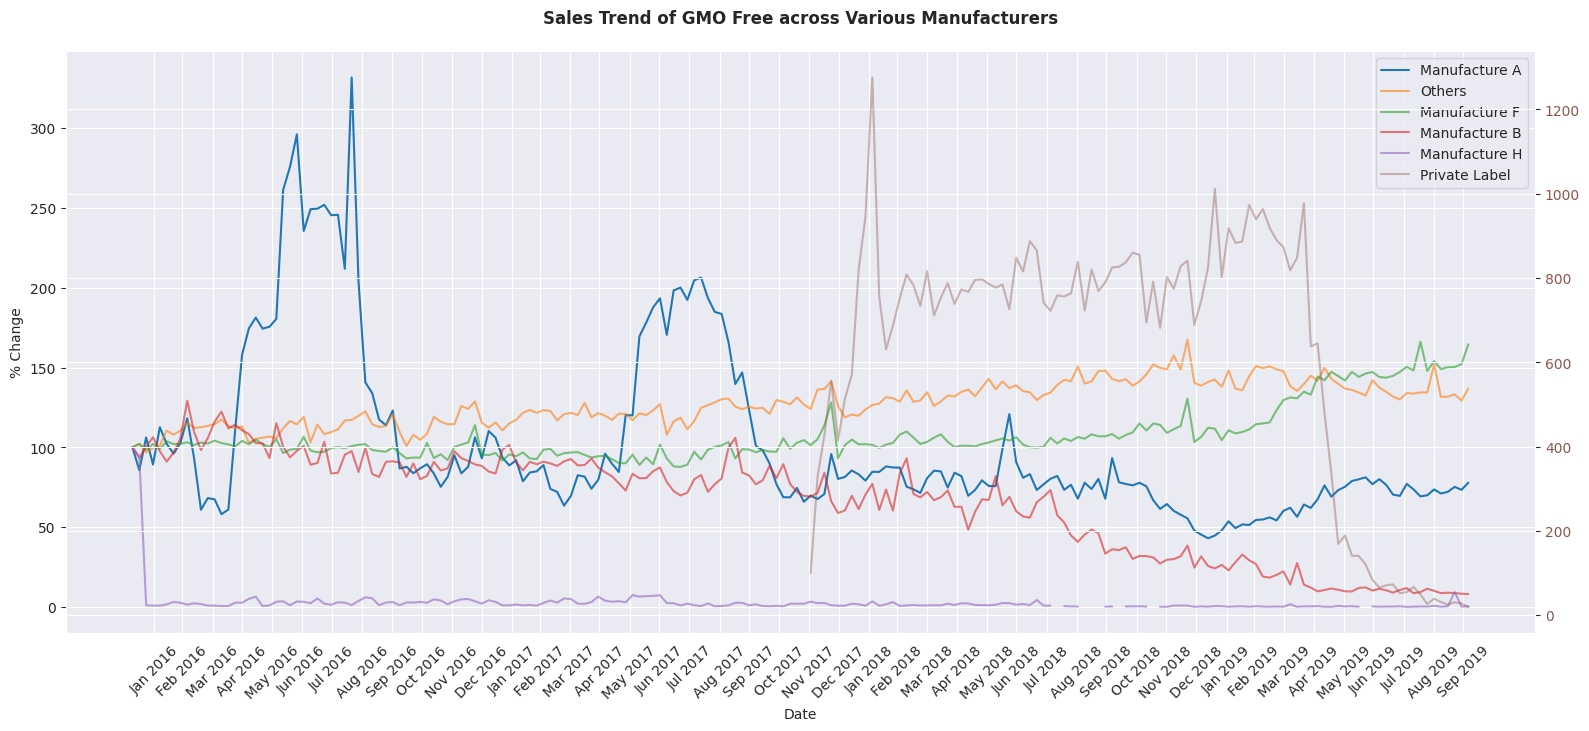

In [ ]:
#we can now peacefully plot the trends

#drop private label as it bounces in sales a lot; refer to the graph later
#twin y-axes plot will be used
data = normalized_vendor_trends.drop('Private Label', axis=1)
index = normalized_vendor_trends.index

fig, ax1 = plt.subplots(figsize=(16, 7))

#plot the main graph
ax1.set_xlabel('Date')
ax1.set_ylabel('% Change')
p1, = ax1.plot(index, data.A, label='Manufacture A')
p2, = ax1.plot(index, data.Others, label='Others', alpha=0.6)
p3, = ax1.plot(index, data.F, label='Manufacture F', alpha=0.6)
p4, = ax1.plot(index, data.B, label='Manufacture B', alpha=0.6)
p5, = ax1.plot(index, data.H, label='Manufacture H', alpha=0.6)

#plot private label with shared x-axis
color = 'tab:brown'
ax2 = ax1.twinx()  # instantiate a second plot that shares the same x-axis
p6, = ax2.plot(index, normalized_vendor_trends['Private Label'], label='Private Label', alpha=0.4, color=color)
ax2.tick_params(axis='y', labelcolor=color)

#create a datetime series to properly annotate x ticks
index = pd.date_range(start=index[0], end=index[-1], freq='M')
ax1.tick_params(axis='x', labelrotation=45)
ax1.set_xticks(list(index))
ax1.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%b %Y'))

fig.tight_layout()  # otherwise the right y-label is slightly clipped
ax1.legend(handles=[p1, p2, p3, p4, p5, p6])
plt.title('Sales Trend of GMO Free across Various Manufacturers', fontweight='semibold', pad=20)

In [ ]:
normalized_vendor_trends.tail()

,Others,A,F,B,H,Private Label
date,,,,,,
2019-09-07,131.608796,71.096045,149.021525,8.665727,0.126783,31.081081
2019-09-14,131.740805,72.133082,150.247121,8.922796,0.422610,25.000000
2019-09-21,133.216972,75.231638,150.326885,8.690605,9.360803,30.405405
2019-09-28,129.314601,73.433773,152.160373,8.284269,0.221870,27.702703
2019-10-05,136.862472,77.855618,164.590913,8.052077,0.348653,19.594595


**Potential Competitors Conclusion:**
Theme: GMO Free,
Client: Manufacturer A
*   Manufacturer B was a good competitor for Manufacturer A in terms of past sales records over 3 years. However, after analyzing the sales trends, Vendor B's trend had been heading downward since its release, and it only had 8% of the initial units sold in Jan 2016. Manufacturer B is expected to lose all of its market share in GMO Free theme in coming months, and thus it is not longer a threat for Manufacturer A.
*   The real potential competitors for Manufacturer A are Manufacturer F and 'Others'. Although 'Others' is inclusive of all the unmentioned manufacturers, its combined sales were remarkable, and Manufacturer A should be on the lookout. In addition, as shown in the market share bubble chart, Others and Vendor F are indeed big manufacturing giants in GMO Free theme; Manufacturer A will have a tough fight against these two giants.
*   Manufacturer A can learn lessons from the downfall of Manufacturer B to plan better ahead.  
*   Although the actual quantity was low, the sales spikes of Private Label was top-of-the-roof, and Manufacturer A should analyze and replicate those spikes.

# Part 2: Recommend Strategies for Business Growth

## 1. Recommend 3 themes with high business opportunity for Manufacturer A. Explain and justify your recommendations by showing supporting evidence through graphs/data obtained from your program codes. (12 marks)

###Data Pre-processing

In [ ]:
#let us analyze the sales of all themes first
print(f'There are {sales_theme} themes contributed to sales.')

There are 49 themes contributed to sales.


In [ ]:
#get the theme_id of products from sales df; same as Q2.4
sales_theme_id = theme_pl[theme_pl.product_id.isin(sales.product_id.unique())]['theme_id'].unique()
sales_theme_id = sales_theme_id[sales_theme_id != 0] #No Claim theme is dropped as it cannot be reasonably said that 'No Claim' theme has potential business opportunity
sales_theme_id

array([  8,  81,  58, 432, 438,  16, 158,  75, 287,  39,  40, 187, 224,
       186, 151, 193, 433,  32, 152, 220, 222, 227, 437,  73, 430, 185,
       120, 385, 100,  15, 207, 163, 228, 192, 142, 125, 147, 148, 101,
       145, 178, 384,  38, 171, 393,  65, 191, 211])

In [ ]:
#three of these sales_theme_id will be used for the recommendation

#to create a new df with date as index and theme_id as columns
#so that the sales trends over 3 years of all 48 themes can be visualized
focused_sales_dict = {}

for theme_id in sales_theme_id: #loop through 48 theme_id in sales
  products = theme_pl[theme_pl.theme_id==theme_id].product_id.values #get product_ids of the respective theme_id
  temp_sales = sales[sales.product_id.isin(products)].groupby('date').sum().drop(['product_id', 'units', 'lbs'], axis=1) #get the sales of those products; group by date; add; take only date and dollar columns
  #dollar column is used instead of units sold to see which theme brings in the most money
  temp_sales.rename(columns={'dollar': theme_id}, inplace=True) #rename dollar to theme_id so that theme_id becomes a column in the new df
  temp_dict = temp_sales.to_dict() #change series to df
  focused_sales_dict.update(temp_dict) #update the dict created beforehand
focused_sales = pd.DataFrame(focused_sales_dict) #dict to df
print(focused_sales.info())
focused_sales.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 196 entries, 2016-01-09 to 2019-10-05
Data columns (total 48 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   8       196 non-null    float64
 1   81      196 non-null    float64
 2   58      196 non-null    float64
 3   432     196 non-null    float64
 4   438     196 non-null    float64
 5   16      196 non-null    float64
 6   158     196 non-null    float64
 7   75      196 non-null    float64
 8   287     196 non-null    float64
 9   39      196 non-null    float64
 10  40      196 non-null    float64
 11  187     196 non-null    float64
 12  224     196 non-null    float64
 13  186     196 non-null    float64
 14  151     196 non-null    float64
 15  193     196 non-null    float64
 16  433     196 non-null    float64
 17  32      196 non-null    float64
 18  152     196 non-null    float64
 19  220     196 non-null    float64
 20  222     196 non-null    float64
 21  227     196 non-null

,8,81,58,432,438,16,158,75,287,39,...,101,145,178,384,38,171,393,65,191,211
2016-01-09,75808110.0,19567288.0,6859282.0,45842629.0,14568867.0,76785.0,1365966.0,907432.0,132198.0,550343.0,...,10280.0,212288.0,71260.0,1751.0,NaN,8207.0,1784.0,NaN,NaN,NaN
2016-01-16,75660104.0,19539368.0,6924311.0,45835085.0,14570166.0,76467.0,1322963.0,890953.0,154539.0,608867.0,...,9035.0,231203.0,73317.0,1751.0,NaN,8655.0,1784.0,NaN,358.0,NaN
2016-01-23,76412434.0,19552112.0,7028671.0,44595447.0,14256774.0,75613.0,1346481.0,901342.0,138554.0,610059.0,...,9168.0,236002.0,73724.0,2873.0,NaN,7388.0,1784.0,NaN,806.0,NaN
2016-01-30,76293121.0,19844286.0,6960231.0,44716545.0,14328455.0,75206.0,1337522.0,972563.0,140200.0,634581.0,...,9447.0,237859.0,59829.0,1751.0,NaN,8212.0,1784.0,NaN,NaN,NaN
2016-02-06,76272682.0,19530176.0,7106895.0,43911232.0,13920787.0,71065.0,1347672.0,989873.0,125049.0,629642.0,...,9777.0,235496.0,65721.0,1751.0,NaN,8347.0,1784.0,NaN,136.0,NaN


In [ ]:
#create a df to see how many vendors produce the same theme_id
#merge theme_pl & manu on product_id; group by theme_id and take only vendor column with unique vendors; reset index
focused_vendor = pd.merge(theme_pl, manu, on='product_id').groupby('theme_id')['vendor'].unique().reset_index()
print(focused_vendor.info())
focused_vendor.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   theme_id  51 non-null     int64 
 1   vendor    51 non-null     object
dtypes: int64(1), object(1)
memory usage: 944.0+ bytes
None


,theme_id,vendor
0,0,"[Others, Private Label, H, B, A, E, D, F, G]"
1,8,"[Others, A, B, F, D, H, Private Label]"
2,15,"[Others, Private Label, A, D]"
3,16,[Others]
4,32,"[Others, A, F, D, H, B]"


In [ ]:
#similar to the method in creating focused_sales; used .pivot() here
focused_search = search.groupby(['date', 'theme_id'], as_index=False).agg({'search_volume': 'sum'}).pivot(index='date', columns='theme_id', values='search_volume')
print(focused_search.info())
focused_search.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2100 entries, 2014-01-01 to 2019-10-01
Columns: 160 entries, 8 to 999
dtypes: float64(160)
memory usage: 2.6 MB
None


theme_id,8,39,40,65,75,79,81,100,101,120,...,970,974,977,979,980,981,982,984,985,999
date,,,,,,,,,,,,,,,,,,,,,
2014-01-01,6613.0,181.0,NaN,NaN,135.0,NaN,1257.0,2636.0,NaN,NaN,...,NaN,24044.0,NaN,306.0,41140.0,NaN,NaN,NaN,NaN,NaN
2014-01-02,6867.0,91.0,NaN,NaN,1078.0,NaN,718.0,659.0,NaN,NaN,...,NaN,34013.0,NaN,611.0,28798.0,NaN,NaN,803.0,NaN,NaN
2014-01-03,4451.0,NaN,NaN,NaN,674.0,NaN,898.0,1318.0,NaN,NaN,...,NaN,31667.0,NaN,NaN,30855.0,NaN,NaN,NaN,NaN,NaN
2014-01-04,6994.0,NaN,NaN,NaN,944.0,NaN,1436.0,NaN,NaN,NaN,...,NaN,28149.0,NaN,306.0,31884.0,NaN,NaN,NaN,NaN,625.0
2014-01-05,5341.0,NaN,NaN,NaN,1617.0,NaN,898.0,NaN,NaN,NaN,...,NaN,28735.0,NaN,1833.0,51425.0,NaN,NaN,NaN,NaN,417.0


###Analysis

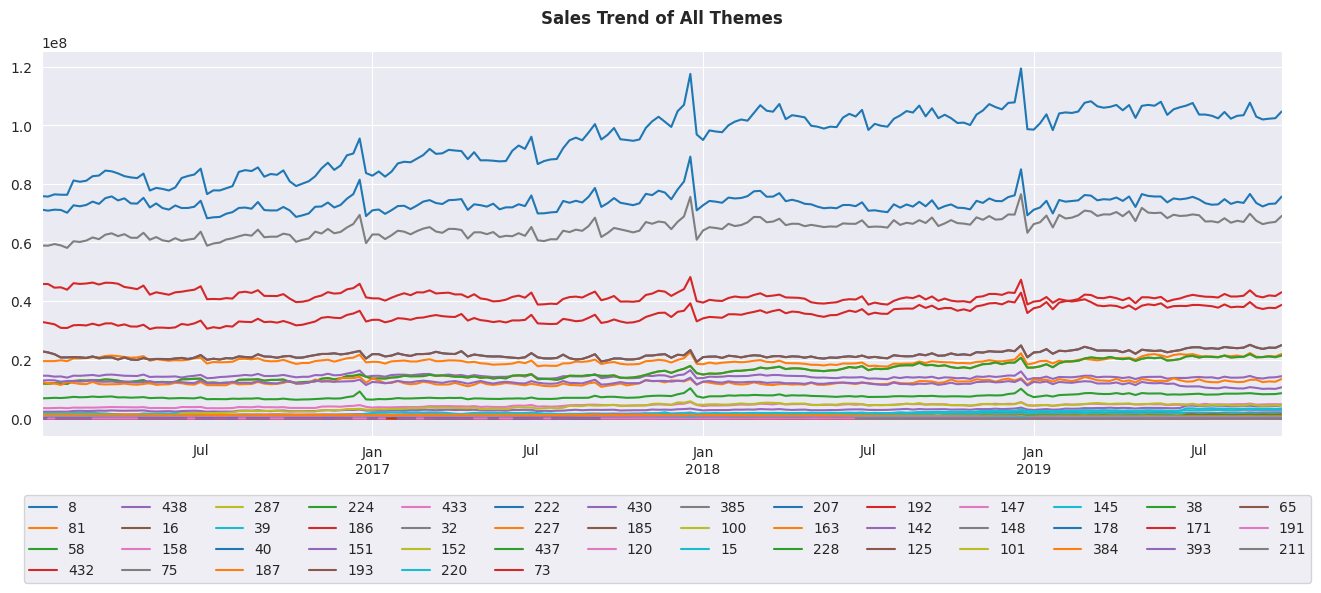

In [ ]:
#a sketch
focused_sales.plot(figsize=(16, 5))
plt.legend(loc='lower left', ncol=14, bbox_to_anchor=(-0.02, -0.4))
plt.title('Sales Trend of All Themes', fontweight='semibold', pad=20)
plt.show()

In [ ]:
#super messy and colors are being repeated

#check the total sales
focused_sales.sum().sort_values(ascending=False).head(10)

8      1.862566e+10
40     1.438821e+10
32     1.275780e+10
432    8.094533e+09
186    7.007307e+09
185    4.254113e+09
222    4.254113e+09
81     3.859459e+09
224    3.137485e+09
187    3.137485e+09
dtype: float64

In [ ]:
#the top themes with the most business growth should bring in the most money in the future
#thus only these 10 themes will be analzyed in details
top_ten_id = focused_sales.sum().sort_values(ascending=False).head(10).index
top_ten_sales = focused_sales.loc[:, top_ten_id]
top_ten_sales.head()

,8,40,32,432,186,185,222,81,224,187
2016-01-09,75808110.0,71191284.0,58975496.0,45842629.0,32938438.0,22895226.0,22895226.0,19567288.0,11892639.0,11892639.0
2016-01-16,75660104.0,70862710.0,58911734.0,45835085.0,32510177.0,22512829.0,22512829.0,19539368.0,11840577.0,11840577.0
2016-01-23,76412434.0,71194364.0,59472359.0,44595447.0,32116796.0,21904525.0,21904525.0,19552112.0,12047308.0,12047308.0
2016-01-30,76293121.0,71097650.0,59012274.0,44716545.0,30889345.0,20804818.0,20804818.0,19844286.0,11944774.0,11944774.0
2016-02-06,76272682.0,70149087.0,58152236.0,43911232.0,30850611.0,20812069.0,20812069.0,19530176.0,11771745.0,11771745.0


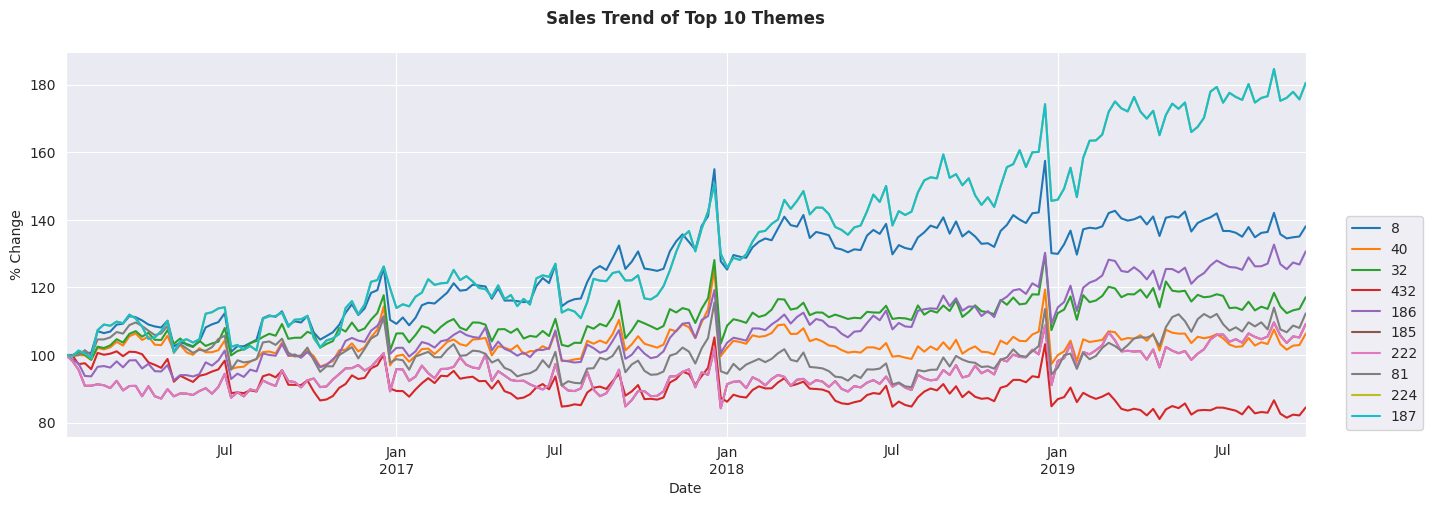

In [ ]:
#normalize the data to see % chg from the initial value
nor_top_ten_sales = top_ten_sales.div(top_ten_sales.iloc[0]).mul(100)
nor_top_ten_sales.plot(figsize=(16, 5))
plt.legend(loc='lower right', bbox_to_anchor=(1.1, 0))
plt.xlabel('Date')
plt.ylabel('% Change')
plt.title('Sales Trend of Top 10 Themes', fontweight='semibold', pad=20)
plt.show()

From the above graph, theme_id 432 is discarded as it is showing a downward trend. Theme_id 187, 8 and 186 currently have the most potential for opportunity both in terms of sales revenue and consistent growth.

In [ ]:
#let us check the public interest for the remaining 9 themes
top_nine_id = top_ten_id.drop(432)
valid_ids = [id for id in top_nine_id if id in focused_search.columns]
top_nine_search = focused_search.loc[:, valid_ids]
top_nine_search.head()

theme_id,8,40,81,187
date,,,,
2014-01-01,6613.0,NaN,1257.0,3905.0
2014-01-02,6867.0,NaN,718.0,1562.0
2014-01-03,4451.0,NaN,898.0,2603.0
2014-01-04,6994.0,NaN,1436.0,3644.0
2014-01-05,5341.0,NaN,898.0,4686.0


In [ ]:
#it seems only theme_id 8, 40, 81 and 187 exist in search data
#percentage of missing value
top_nine_search.isnull().sum().div(len(top_nine_search)).mul(100)

theme_id
8       0.000000
40     98.047619
81      6.095238
187     0.047619
dtype: float64

Pearson R = 0.44
Pearson P = 0.00


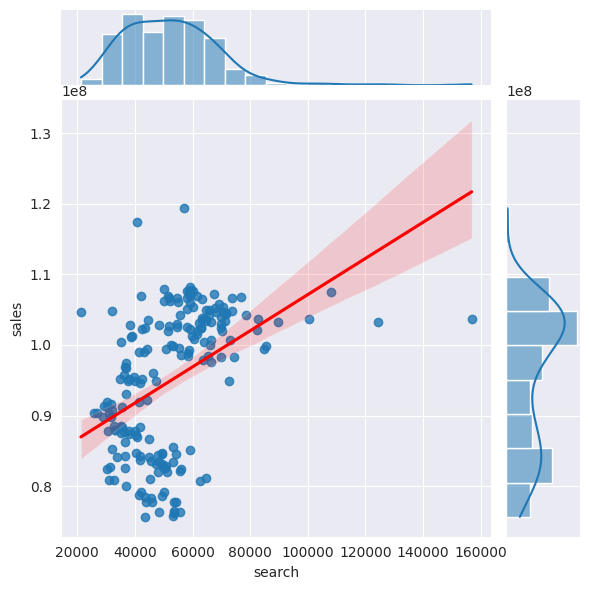

In [ ]:
#in Q4.2, it has been shown that the correlation between sales and search trends is not strong enough to make any conclusion for theme_id 81: GMO Free
#let us see how it goes with theme_id 8; if the there is no clear correlation again, we'll discard the search_volume metric in determining the top 3 potential themes
def corr_check(id):
  specified_theme = pd.concat([focused_sales.loc[:, id], focused_search.loc[:, id].resample('W-SAT').sum()], axis=1, join='inner')
  specified_theme.columns = ['sales', 'search']
  assert specified_theme.isnull().sum().sum() == 0 #ensuring there are no null values
  corr = stats.pearsonr(specified_theme.search, specified_theme.sales)
  sns.jointplot(x='search', y='sales', data=specified_theme, kind='reg', line_kws=dict(color="r"))
  print(f'Pearson R = {corr[0]:.2f}\nPearson P = {corr[1]:.2f}')
  plt.show()
corr_check(8)

Pearson R = 0.62
Pearson P = 0.00


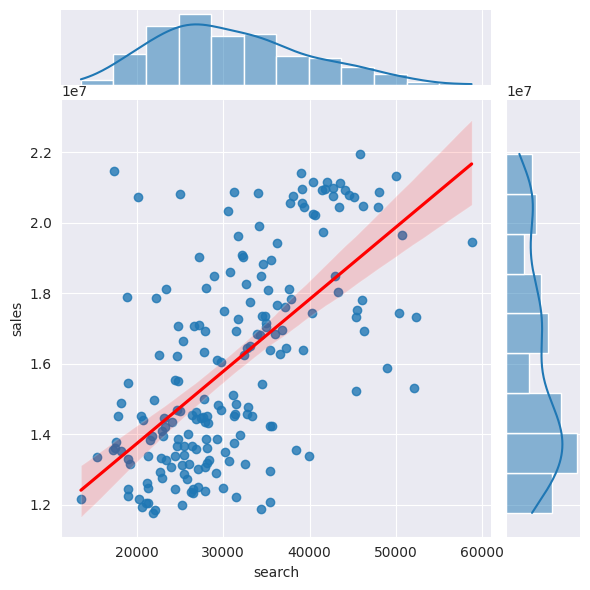

In [ ]:
#moderate correlation; try the same for theme_id 187
corr_check(187)

In [ ]:
#strong correlation

There will be bonus points for theme_id 8 and 187 as they have moderate to strong correlation with search_volume, indicting that people are browsing and buying those two themes. Theme_id 40 has too many null search_volume values to be compared. Theme_id 81 is mentioned in Q4.2. As for the rest of the themes, no search interest is involved. This shouldn't be a metric to exclude them as there is not enough information to know whether there is a correlation between sales and search trends

In [ ]:
#now, let us see how many competitors are there for each theme
top_nine_vendor = focused_vendor[focused_vendor.theme_id.isin(top_nine_id)].reset_index(drop=True)
top_nine_vendor

,theme_id,vendor
0,8,"[Others, A, B, F, D, H, Private Label]"
1,32,"[Others, A, F, D, H, B]"
2,40,"[Others, A, B, F, D, H, Private Label]"
3,81,"[Others, A, F, H, B, Private Label]"
4,185,"[Others, B, A, D, H, F, Private Label]"
5,186,"[Others, A, B, F, D, H, Private Label]"
6,187,"[Others, A, F, D, B, H, Private Label]"
7,222,"[Others, B, A, D, H, F, Private Label]"
8,224,"[Others, A, F, D, B, H, Private Label]"


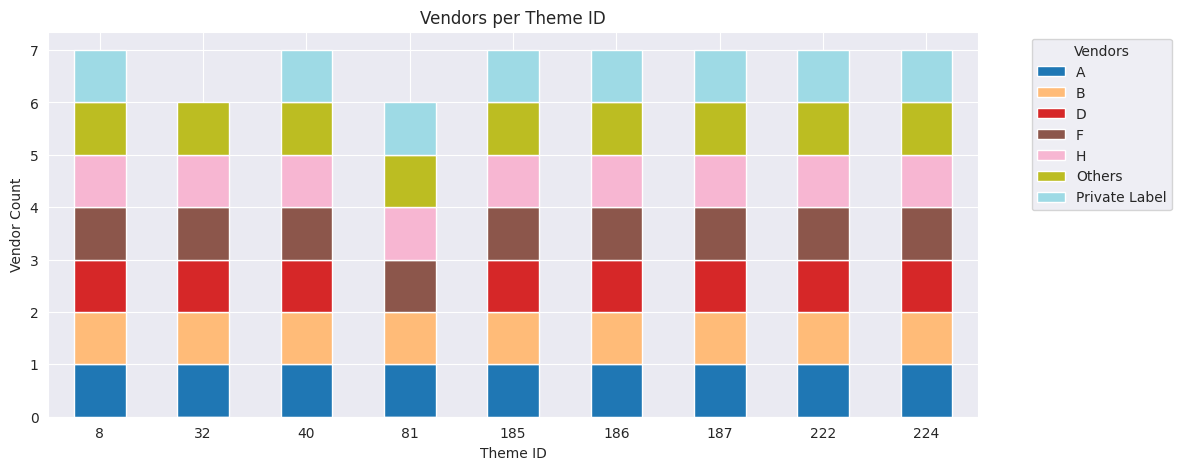

In [ ]:
#let us visualize
# Create a binary matrix for vendors
all_vendors = sorted(set(v for vendors in top_nine_vendor['vendor'] for v in vendors))
vendor_matrix = {vendor: [] for vendor in all_vendors}

for vendors in top_nine_vendor['vendor']:
    for vendor in all_vendors:
        vendor_matrix[vendor].append(1 if vendor in vendors else 0)

vendor_df = pd.DataFrame(vendor_matrix)
vendor_df['theme_id'] = top_nine_vendor['theme_id']
vendor_df.set_index('theme_id', inplace=True)

# Plotting the stacked bar chart
vendor_df.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='tab20')
plt.xlabel('Theme ID')
plt.ylabel('Vendor Count')
plt.title('Vendors per Theme ID')
plt.legend(title='Vendors', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

In [ ]:
#as the competitors are all making products in these themes, it would be hard to decide from just this
#let us analyze the sales trend of each theme across diff vendors
#put everything from Q6 into a function
def theme_compare(theme_id, min=None, max=None):
  specific_products = theme_pl[theme_pl.theme_id==theme_id].product_id.values
  df = sales[sales.product_id.isin(specific_products)].drop(['dollar', 'lbs'], axis=1).merge(manu, on='product_id').drop('product_id', axis=1)
  sales_trend_by_vendor = pd.DataFrame()

  for vendor in df.vendor.unique():
    sales_trend_by_vendor[vendor] = df[df.vendor==vendor].groupby('date').sum().drop('vendor', axis=1).units

  normalized_vendor_trends = sales_trend_by_vendor.div(sales_trend_by_vendor.iloc[0]).mul(100)

  ax = normalized_vendor_trends.plot(figsize=(14, 5))
  plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
  plt.xlabel('Date')
  plt.ylabel('% Change')
  ax.set_ylim(min, max)
  plt.title(f'Sales Trend of Theme_ID {theme_id}', fontweight='semibold', pad=20)
  plt.show()

In [ ]:
#put the bubble chart of market share from Q6 into a function
def bubble_market_share(id):
  products = theme_pl[theme_pl.theme_id==id].product_id.values #get product_ids of the respective theme_id
  temp_sales = sales[sales.product_id.isin(products)].drop(['date', 'units', 'lbs'], axis=1).reset_index(drop=True)
  theme_manu_sales = temp_sales.merge(manu, on='product_id').groupby('vendor').sum().sort_values(by='dollar', ascending=False).drop(columns=['product_id'])

  fig, ax1 = plt.subplots(subplot_kw=dict(aspect="equal"))

  bubble_chart = BubbleChart(area=theme_manu_sales.dollar, bubble_spacing=0.1)
  bubble_chart.collapse()
  bubble_chart.plot(ax1, theme_manu_sales.index, sns.color_palette("pastel"))
  ax1.axis("off")
  ax1.relim()
  ax1.autoscale_view()
  ax1.set_title(f'Theme_ID {id} Market Share')

  plt.show()

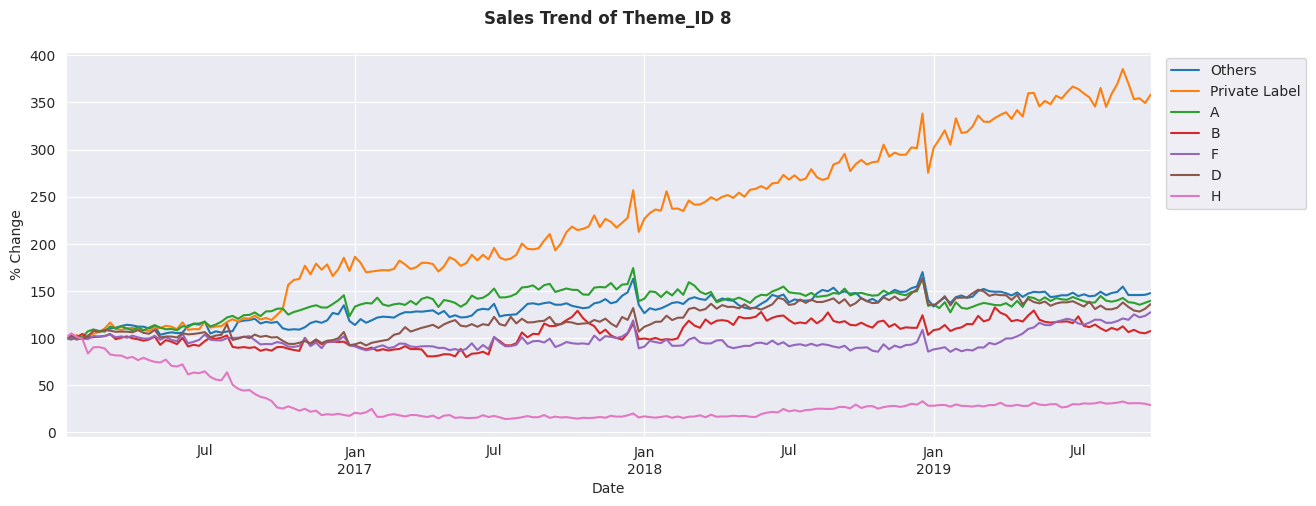

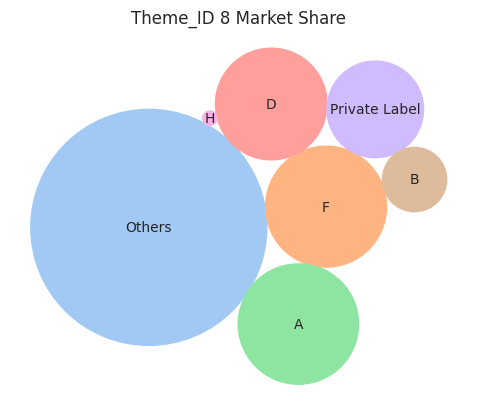

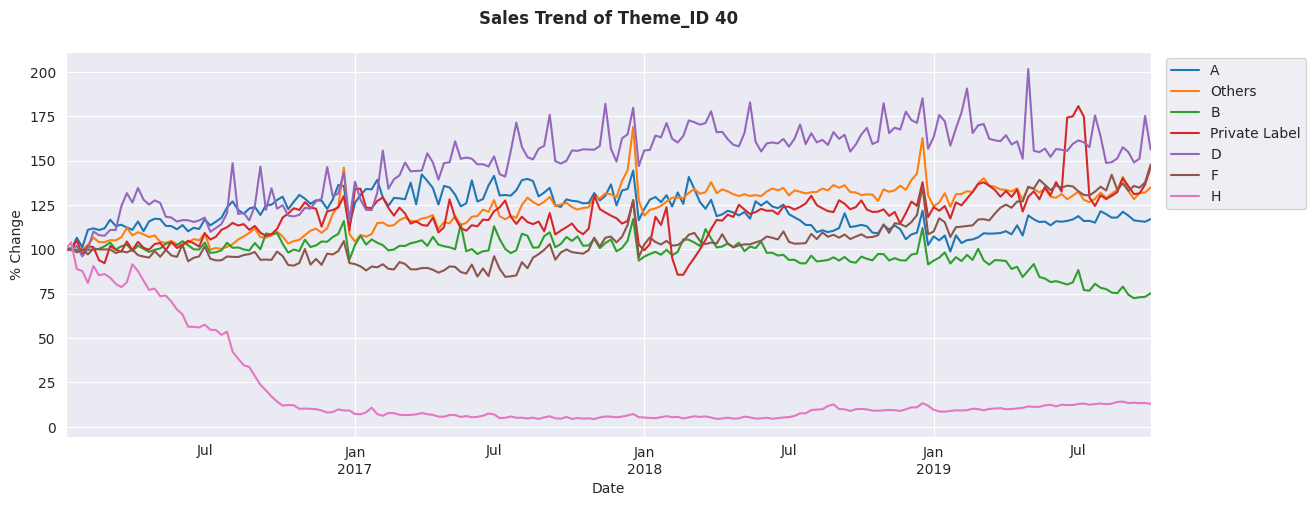

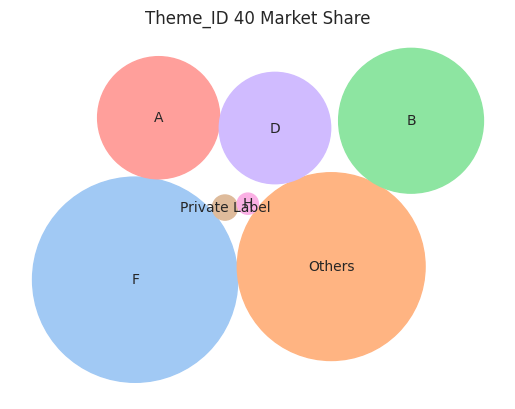

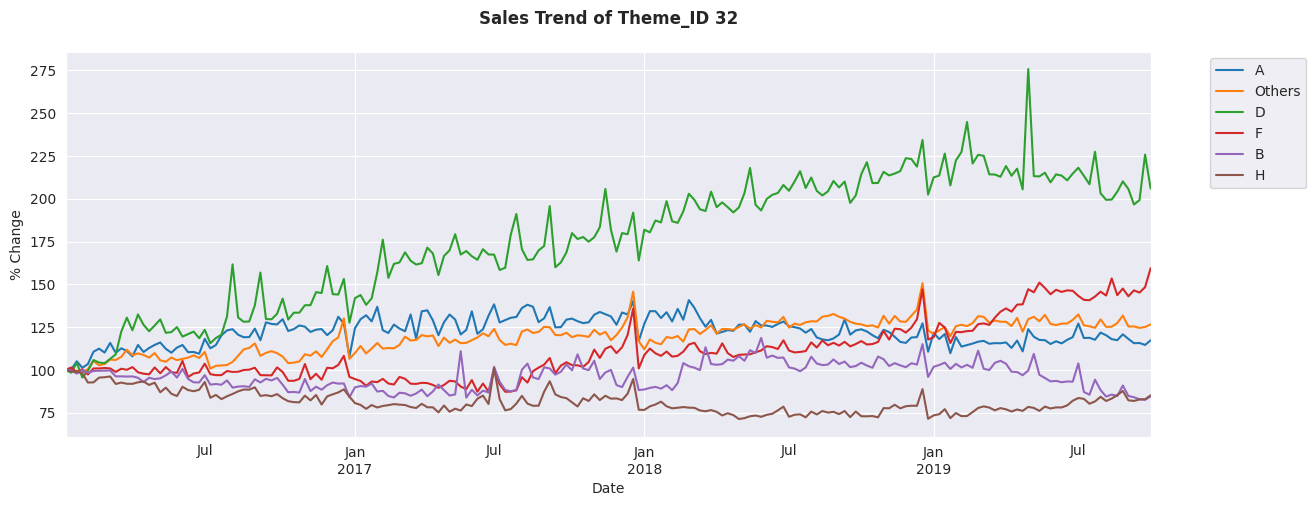

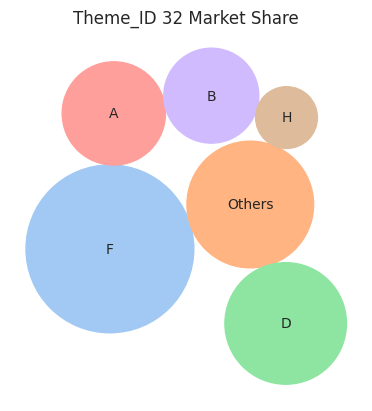

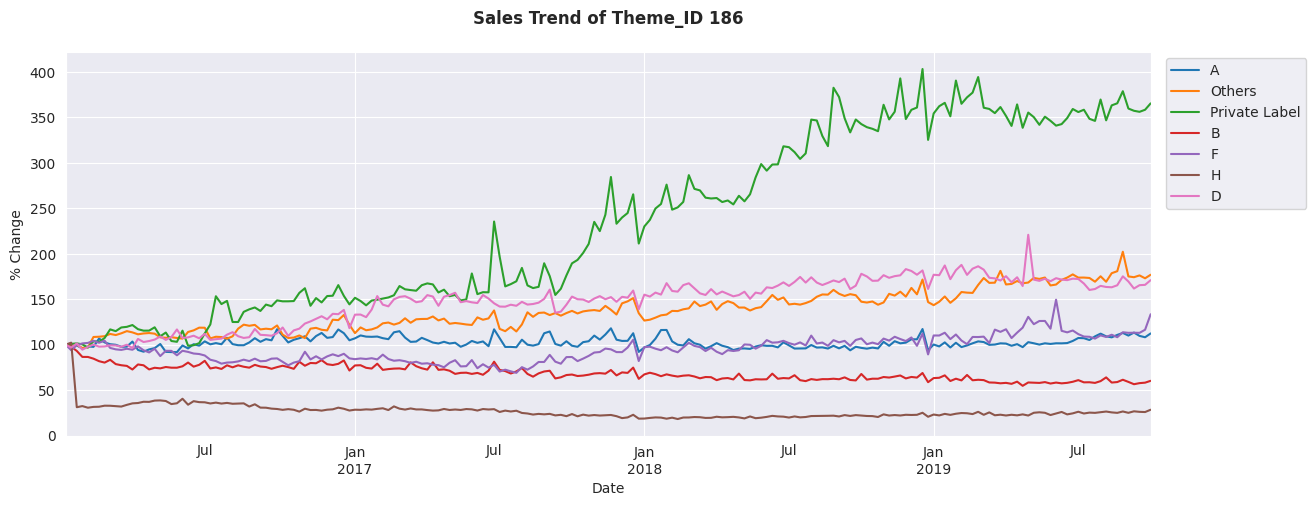

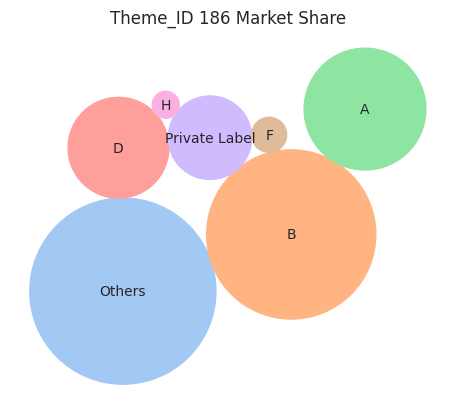

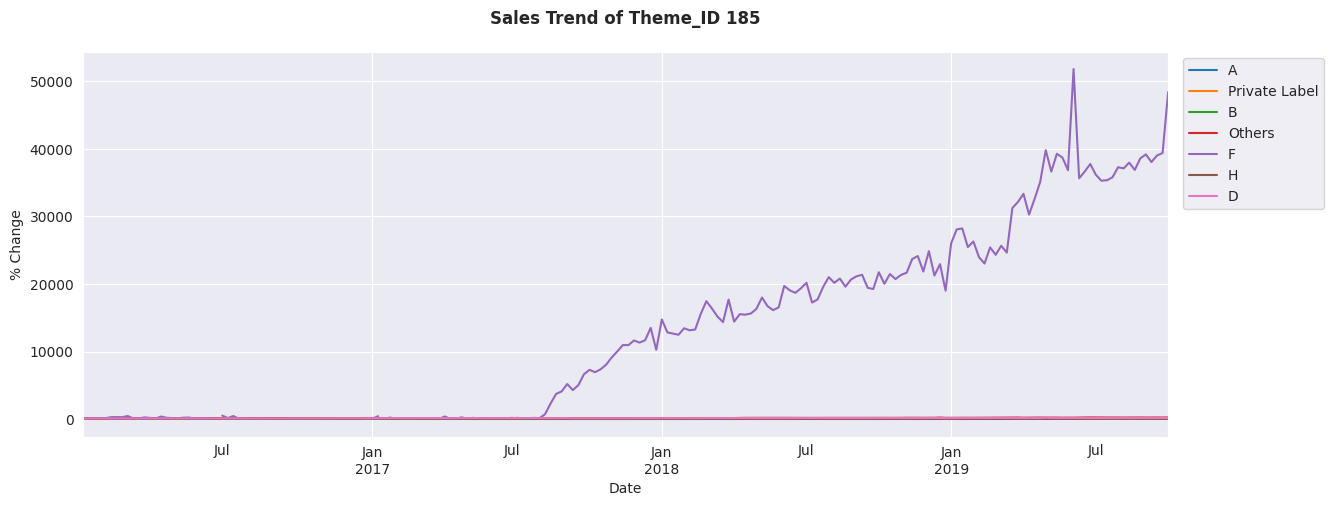

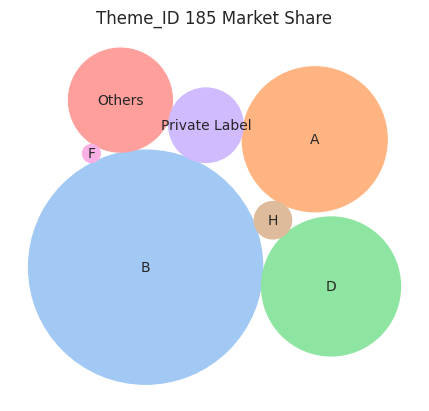

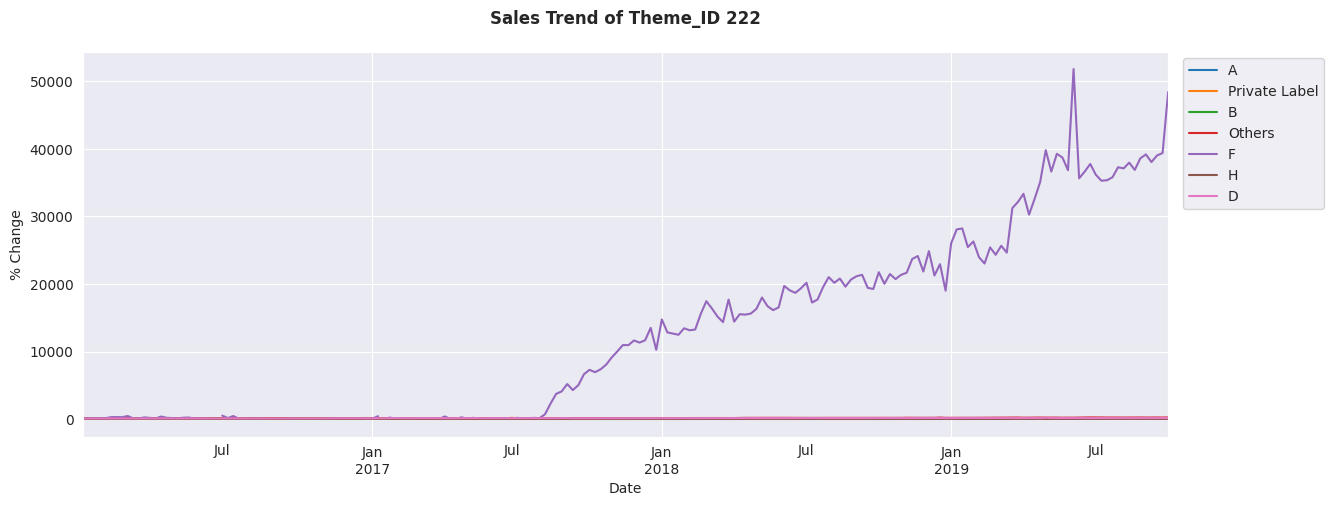

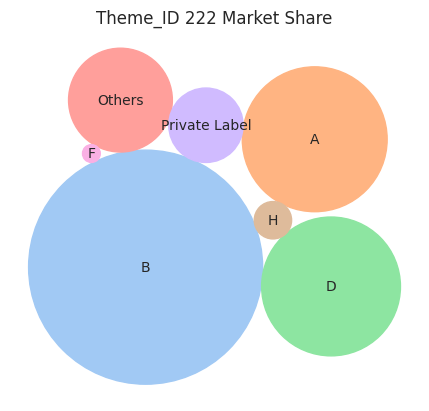

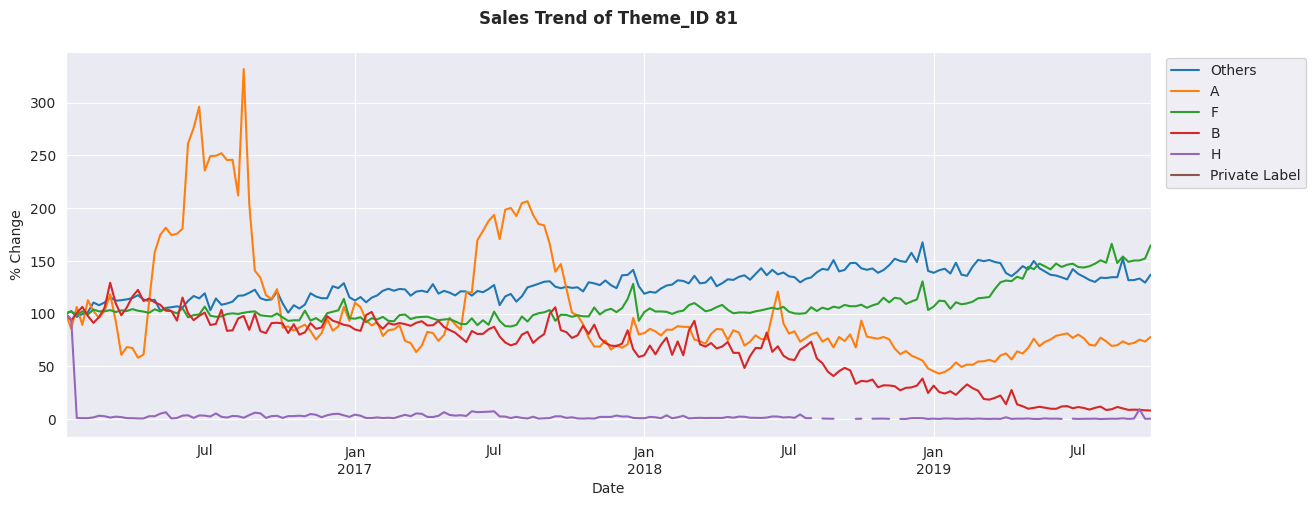

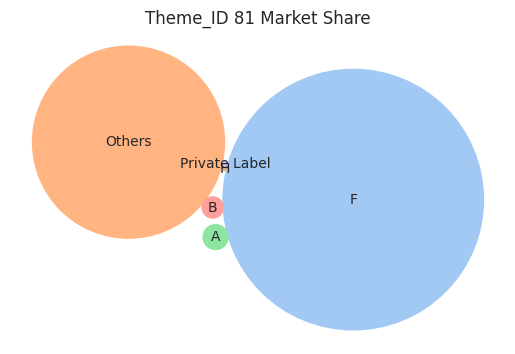

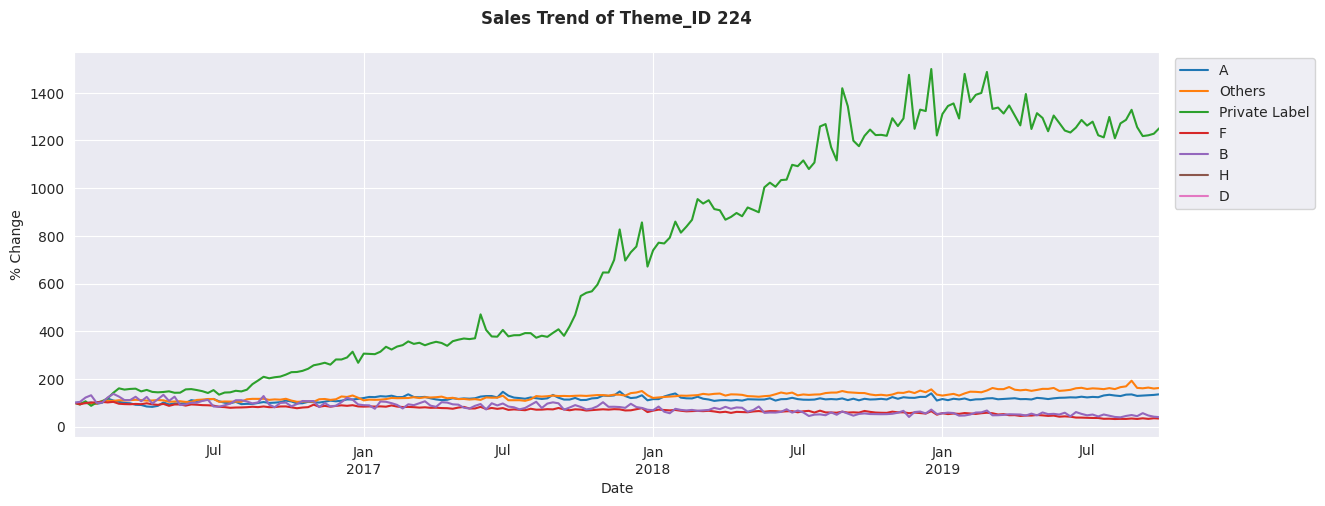

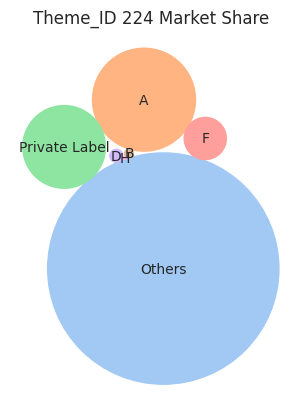

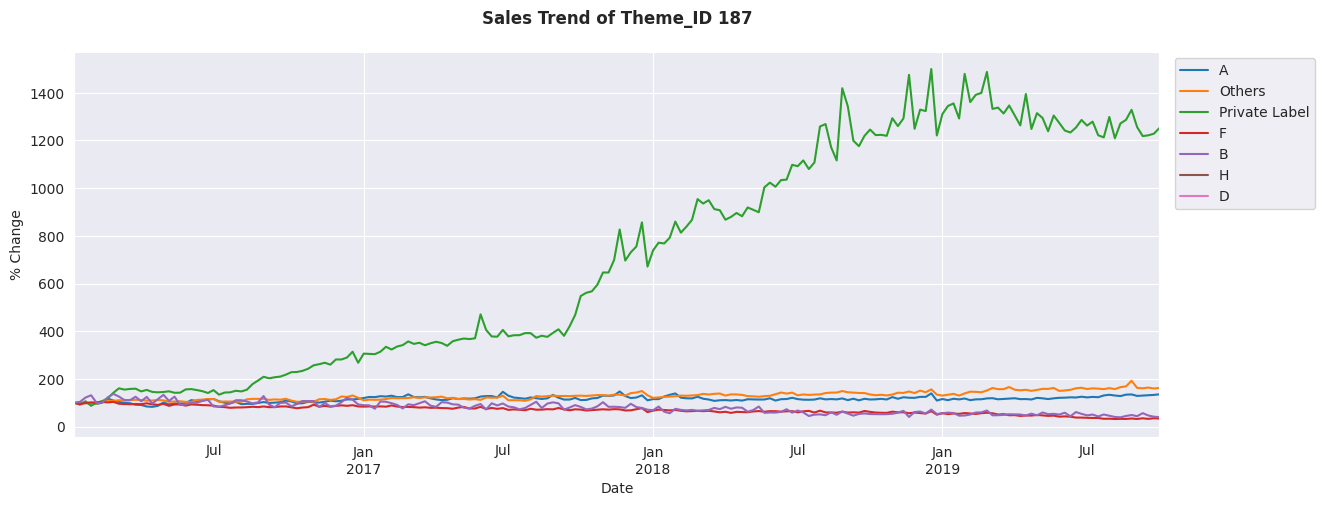

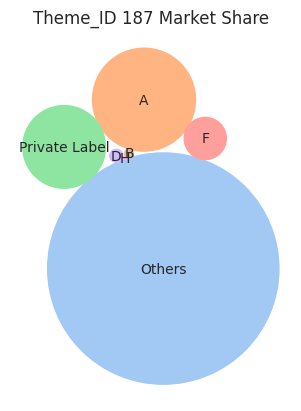

In [ ]:
#throw all nine theme_ids into the func
for id in top_nine_id:
  #mass-producing plots to be added to the ppt
  theme_compare(id)
  bubble_market_share(id)

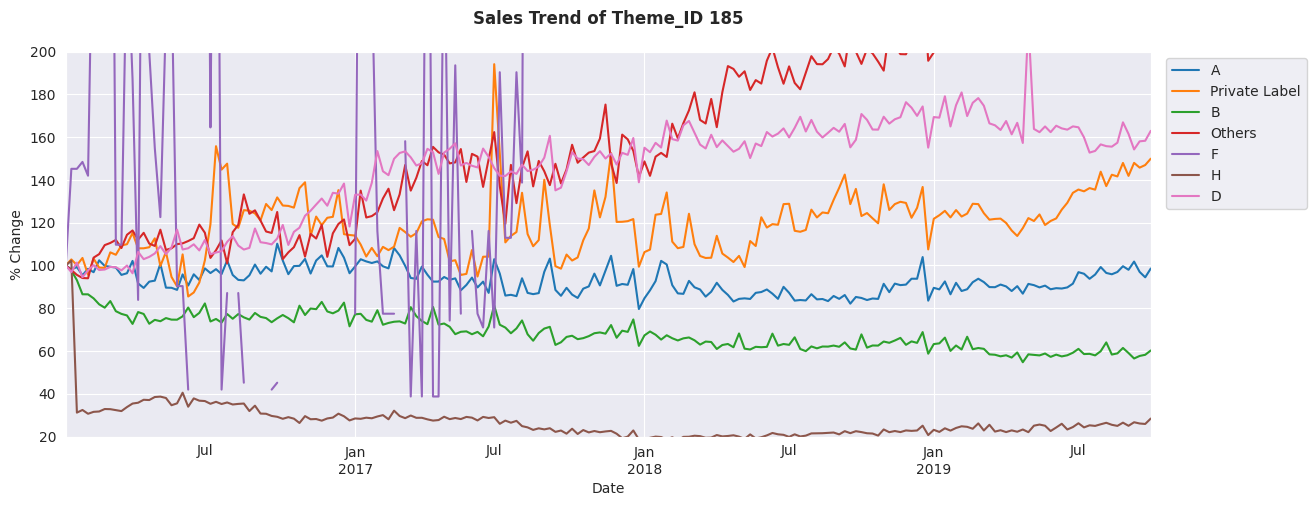

In [ ]:
theme_compare(185, 20, 200)

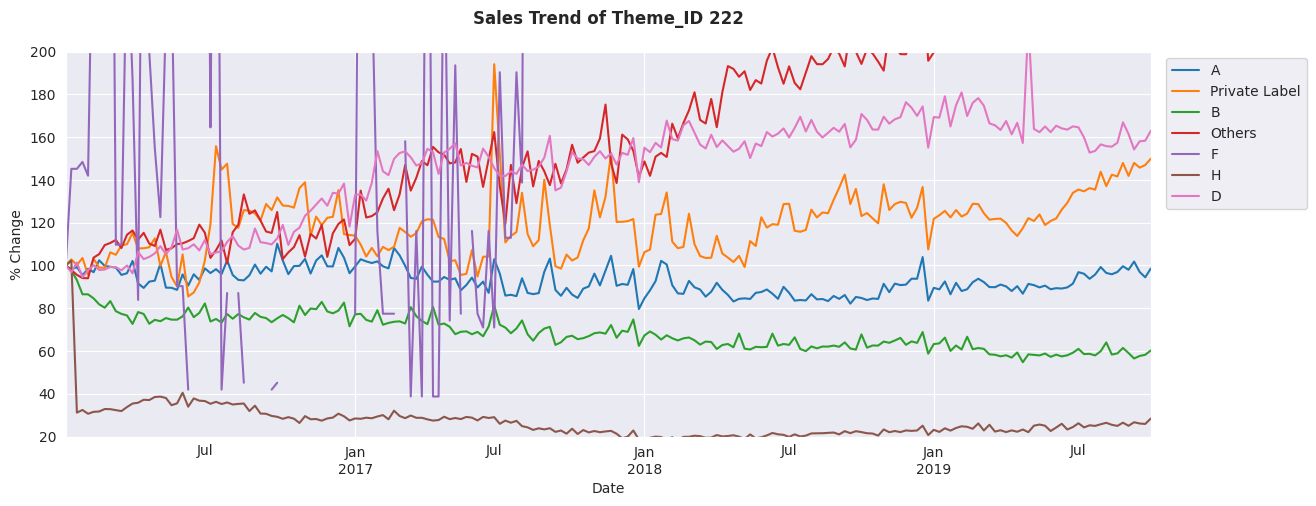

In [ ]:
theme_compare(222, 20, 200)

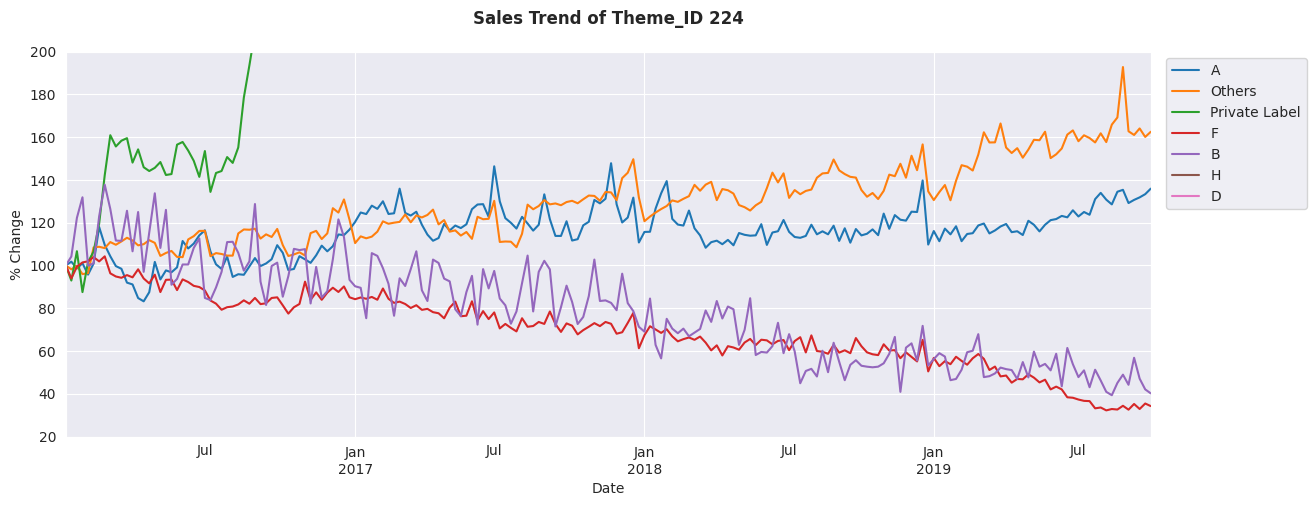

In [ ]:
theme_compare(224, 20, 200)

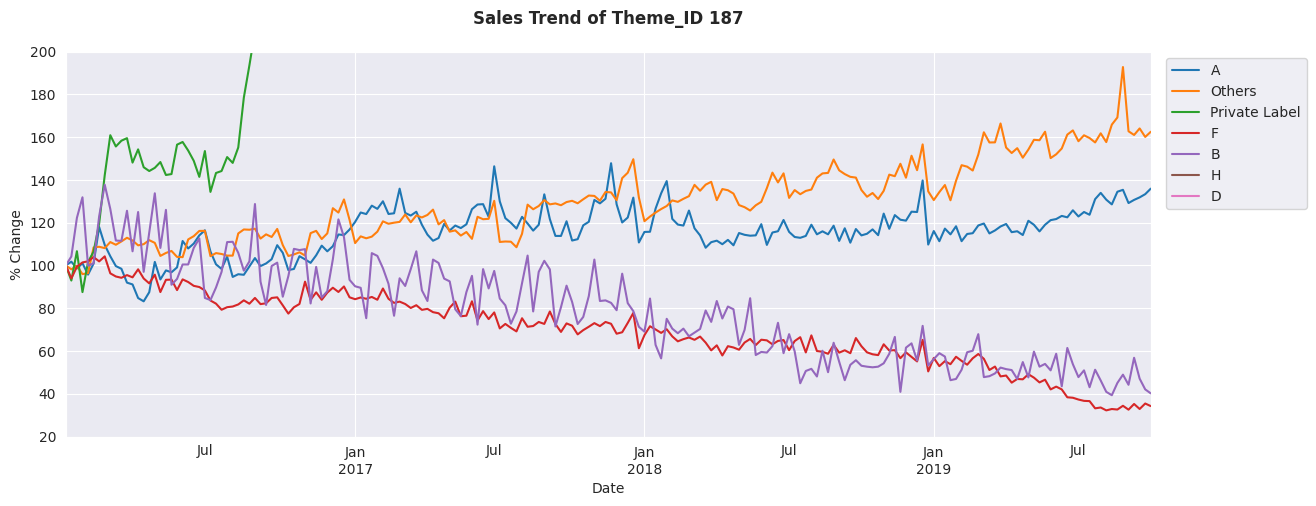

In [ ]:
theme_compare(187, 20, 200)

In [ ]:
#social media data data will not be used here as we do not wish to take the risk without confirming whether the posts have positive or negative sentiment


#referring back to the pie chart market share in Q5
#Vendor A has
#Vendor H & Private Label have small market shares
#while D is a minor

In [ ]:
theme_l[theme_l.theme_id.isin(top_nine_id)]

,theme_id,theme_name
1,8,low carb
5,32,stroganoff
8,40,no additives/preservatives
16,81,gmo free
38,185,cookie
39,186,pollock
40,187,blueberry
48,222,pizza
49,224,american southwest style


**Recommendation Conclusion**
*   Theme_ID 8: Low Carb
*   Theme_ID 224: American southwest style
*   Theme_ID 187: Blueberry

These three themes are believed to bring the highest business growth and opportunities for Manufacturer A.

The reasons being:
*   one of the highest sales revenue drivers (first, ninth & tenth respectively)
*   theme_8 and theme_187 have moderate to strong correlations with search trends, which could be a starting point for targeted marketing strategies.
*   the market share is fair, and thus there is room for competition and business growth
*   the previous sales trends showed a noticeable upward trend, leading to more sales in the future.

The other themes are rejected:
*  the previous sales trends did not show consistent growth, often struggling at equilibrium and sometimes falling under
*  there is no strong correlation of not enough information for search trend comparison
* often times, some giant companies, Others and F, are dominating the market, which makes the competition fierce and unfair.